# Video Prediction World Model
**VAE · ConvLSTM · Spatial Transformer · VQ-VAE + GPT — on Moving MNIST**


## Sections
1. Setup & Imports  
2. Moving MNIST Dataset  
3. Variational Autoencoder (VAE)  
4. 2-Layer ConvLSTM Dynamics Model  
5. Spatial Transformer Dynamics Model  
6. Stochastic Future Rollouts  
7. VQ-VAE  
8. GPT World Model (Discrete Token Prediction)  
9. Evaluation & LinkedIn Visualizations  


## 1. Setup & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install torch torchvision matplotlib scikit-image imageio tqdm -q


In [3]:
import math, random, os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

SAVE_PATH = '/content/drive/MyDrive/WorldModel'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'Checkpoints: {SAVE_PATH}')


PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
Checkpoints: /content/drive/MyDrive/WorldModel


## 2. Moving MNIST Dataset

Each sample is a **20-frame sequence** (T=20, C=1, H=64, W=64):
- Frames `0–9`  → observed context fed to the model  
- Frames `10–19` → prediction targets  

A single MNIST digit bounces around a 64×64 canvas with random velocity and wall reflection.


In [4]:
mnist_raw = MNIST(root='./data', train=True, download=True)
digits = mnist_raw.data.numpy()   # (60000, 28, 28)


class MovingMNIST(Dataset):
    """On-the-fly Moving MNIST sequence generator."""

    def __init__(self, seq_len=20, image_size=64, dataset_size=10_000):
        self.seq_len = seq_len
        self.image_size = image_size
        self.dataset_size = dataset_size

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        digit = digits[random.randint(0, len(digits) - 1)]
        x = random.randint(0, self.image_size - 28)
        y = random.randint(0, self.image_size - 28)
        dx = random.choice([-2, -1, 1, 2])
        dy = random.choice([-2, -1, 1, 2])

        frames = []
        for _ in range(self.seq_len):
            canvas = np.zeros((self.image_size, self.image_size), dtype=np.float32)
            canvas[y:y+28, x:x+28] = digit / 255.0
            frames.append(canvas)

            x = max(0, min(x + dx, self.image_size - 28))
            y = max(0, min(y + dy, self.image_size - 28))
            if x in (0, self.image_size - 28): dx *= -1
            if y in (0, self.image_size - 28): dy *= -1

        return torch.tensor(np.array(frames)).unsqueeze(1)   # (T, 1, H, W)


dataset    = MovingMNIST()
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
print(f'Dataset ready  |  sample shape: {dataset[0].shape}')


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]

Dataset ready  |  sample shape: torch.Size([20, 1, 64, 64])


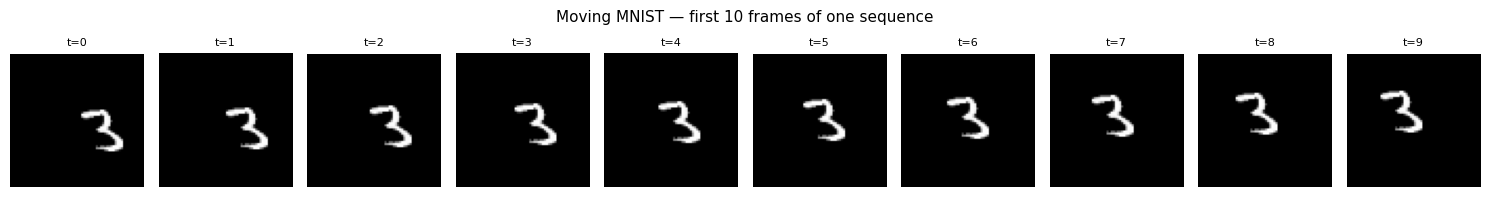

In [5]:
# Visualise one sequence
sample = dataset[0]
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle('Moving MNIST — first 10 frames of one sequence', fontsize=11)
for i, ax in enumerate(axes):
    ax.imshow(sample[i, 0], cmap='gray')
    ax.set_title(f't={i}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Variational Autoencoder (VAE)

The VAE compresses each 64×64 frame into a **128-channel 8×8 spatial latent map**,
preserving spatial structure for downstream dynamics models.

| Stage | Layer | Output Shape |
|-------|-------|-------------|
| Encoder | 3× Conv2d (stride=2) | (128, 8, 8) |
| Reparameterize | μ + ε·σ | (128, 8, 8) |
| Decoder | 3× ConvTranspose2d | (1, 64, 64) |

**Loss:**  
$$\mathcal{L} = \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KL}}$$  
We use `reduction='sum'` for proper scaling (β=1.0 standard VAE).


In [6]:
class VAE(nn.Module):
    """Convolutional VAE — produces spatial latent maps, not flat vectors."""

    def __init__(self, latent_channels=128):
        super().__init__()
        self.latent_channels = latent_channels

        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, latent_channels * 2, 4, stride=2, padding=1),  # mu & logvar together
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32,  1, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar):
    """Properly scaled ELBO loss."""
    B = x.size(0)
    recon_loss = F.mse_loss(recon, x, reduction='sum') / B
    kl_loss    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum() / B
    return recon_loss + kl_loss, recon_loss, kl_loss


vae = VAE().to(device)
print(vae)


VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [7]:
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

vae_train_losses = []   # track for LinkedIn chart
epochs = 20

vae.train()
for epoch in range(epochs):
    total = 0
    for batch in tqdm(dataloader, desc=f'VAE Epoch {epoch+1}/{epochs}'):
        frames = batch[:, 0].to(device)           # train on all frames, not just frame 0
        optimizer.zero_grad()
        recon, mu, logvar = vae(frames)
        loss, _, _ = vae_loss(recon, frames, mu, logvar)
        loss.backward()
        optimizer.step()
        total += loss.item()
    avg = total / len(dataloader)
    vae_train_losses.append(avg)
    print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {avg:.4f}')

torch.save({'model': vae.state_dict(), 'losses': vae_train_losses},
           f'{SAVE_PATH}/vae.pth')
print('VAE saved.')


VAE Epoch 1/20: 100%|██████████| 625/625 [00:09<00:00, 66.96it/s]


  Epoch 01/20  Loss: 97.7965


VAE Epoch 2/20: 100%|██████████| 625/625 [00:08<00:00, 73.03it/s]


  Epoch 02/20  Loss: 73.2332


VAE Epoch 3/20: 100%|██████████| 625/625 [00:07<00:00, 88.74it/s]


...

  Epoch 18/20  Loss: 59.0398


VAE Epoch 19/20: 100%|██████████| 625/625 [00:08<00:00, 72.99it/s]


  Epoch 19/20  Loss: 58.4603


VAE Epoch 20/20: 100%|██████████| 625/625 [00:06<00:00, 89.67it/s]


  Epoch 20/20  Loss: 58.3741
VAE saved.


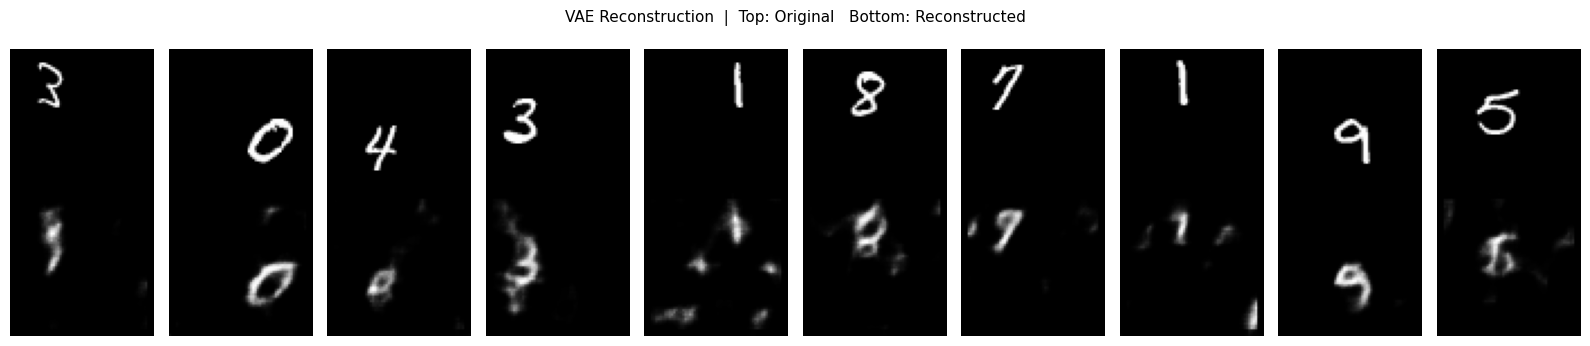

Saved → vae_reconstruction.png


In [8]:
# ── VAE Reconstruction Quality ──────────────────────────────────────────
vae.eval()
with torch.no_grad():
    batch  = next(iter(dataloader))
    frames = batch[:, 0].to(device)
    recon, _, _ = vae(frames)

frames = frames.cpu(); recon = recon.cpu()

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle('VAE Reconstruction  |  Top: Original   Bottom: Reconstructed', fontsize=11)
for i in range(10):
    axes[0, i].imshow(frames[i, 0], cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i, 0],  cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',    fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/vae_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vae_reconstruction.png')


## 4. 2-Layer ConvLSTM Dynamics Model

ConvLSTM extends standard LSTM to operate on spatial feature maps instead of vectors.
This lets the model track **where** things are moving, not just aggregate statistics.

$$h_t, c_t = \text{ConvLSTMCell}(z_t, h_{t-1}, c_{t-1})$$

Two stacked layers give the model richer temporal representations.


In [9]:
class ConvLSTMCell(nn.Module):
    """Single ConvLSTM cell operating on (B, C, H, W) tensors."""

    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(in_channels + hidden_channels,
                              4 * hidden_channels, kernel_size, padding=pad)

    def forward(self, x, h, c):
        gates  = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = gates.chunk(4, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, spatial_size, device):
        H, W = spatial_size
        h = torch.zeros(batch_size, self.hidden_channels, H, W, device=device)
        c = torch.zeros(batch_size, self.hidden_channels, H, W, device=device)
        return h, c


class LatentDynamicsModel(nn.Module):
    """Two stacked ConvLSTM layers for latent dynamics prediction."""

    def __init__(self, latent_channels=128):
        super().__init__()
        self.cell1 = ConvLSTMCell(latent_channels, latent_channels)
        self.cell2 = ConvLSTMCell(latent_channels, latent_channels)

    def forward(self, latent_seq, device=None):
        """
        Args:
            latent_seq: (B, T, C, H, W)
        Returns:
            outputs:    (B, T, C, H, W)  — predicted latent at each step
        """
        B, T, C, H, W = latent_seq.shape
        dev = latent_seq.device
        h1, c1 = self.cell1.init_hidden(B, (H, W), dev)
        h2, c2 = self.cell2.init_hidden(B, (H, W), dev)
        outputs = []
        for t in range(T):
            h1, c1 = self.cell1(latent_seq[:, t], h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)
            outputs.append(h2)
        return torch.stack(outputs, dim=1)


dynamics_model = LatentDynamicsModel().to(device)
print('ConvLSTM Dynamics Model ready.')


ConvLSTM Dynamics Model ready.


In [10]:
def encode_sequence(vae, frames_seq):
    """Encode a (B, T, 1, H, W) sequence → (B, T, C, H, W) latent maps."""
    B, T = frames_seq.shape[:2]
    latents = []
    for t in range(T):
        mu, _ = vae.encode(frames_seq[:, t])
        latents.append(mu)
    return torch.stack(latents, dim=1)


dynamics_optimizer = optim.Adam(dynamics_model.parameters(), lr=1e-3)

# Freeze VAE
for p in vae.parameters(): p.requires_grad = False
vae.eval()

dynamics_losses = []
epochs = 20

dynamics_model.train()
for epoch in range(epochs):
    total = 0
    for batch in tqdm(dataloader, desc=f'Dynamics Epoch {epoch+1}/{epochs}'):
        batch = batch.to(device)
        input_seq  = batch[:, :10]
        target_seq = batch[:, 10:]

        with torch.no_grad():
            lat_in  = encode_sequence(vae, input_seq)   # (B,10,C,H,W)
            lat_tgt = encode_sequence(vae, target_seq)  # (B,10,C,H,W)

        pred_latents = dynamics_model(lat_in)            # (B,10,C,H,W)
        loss = F.mse_loss(pred_latents, lat_tgt)

        dynamics_optimizer.zero_grad()
        loss.backward()
        dynamics_optimizer.step()
        total += loss.item()

    avg = total / len(dataloader)
    dynamics_losses.append(avg)
    print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {avg:.6f}')

torch.save({'model': dynamics_model.state_dict(), 'losses': dynamics_losses},
           f'{SAVE_PATH}/dynamics.pth')
print('Dynamics model saved.')


Dynamics Epoch 1/20: 100%|██████████| 625/625 [00:26<00:00, 23.63it/s]


  Epoch 01/20  Loss: 0.003457


Dynamics Epoch 2/20: 100%|██████████| 625/625 [00:27<00:00, 22.63it/s]


  Epoch 02/20  Loss: 0.002809


Dynamics Epoch 3/20: 100%|██████████| 625/625 [00:26<00:00, 23.67it/s]


...

  Epoch 18/20  Loss: 0.002044


Dynamics Epoch 19/20: 100%|██████████| 625/625 [00:26<00:00, 23.48it/s]


  Epoch 19/20  Loss: 0.002012


Dynamics Epoch 20/20: 100%|██████████| 625/625 [00:26<00:00, 23.73it/s]


  Epoch 20/20  Loss: 0.002009
Dynamics model saved.


In [11]:
def autoregressive_rollout(vae, dynamics_model, input_seq, steps=10):
    """Recursively predict `steps` future frames from observed input_seq."""
    vae.eval(); dynamics_model.eval()
    with torch.no_grad():
        current_seq = encode_sequence(vae, input_seq)  # (B,T,C,H,W)
        predictions = []
        for _ in range(steps):
            pred_latents = dynamics_model(current_seq)
            next_lat     = pred_latents[:, -1]              # take last step
            pred_frame   = vae.decode(next_lat)
            predictions.append(pred_frame.cpu())
            # re-encode and slide window
            next_lat_re = vae.encode(pred_frame)[0].unsqueeze(1)
            current_seq = torch.cat([current_seq[:, 1:], next_lat_re], dim=1)
    return torch.stack(predictions, dim=1)  # (B, steps, 1, H, W)


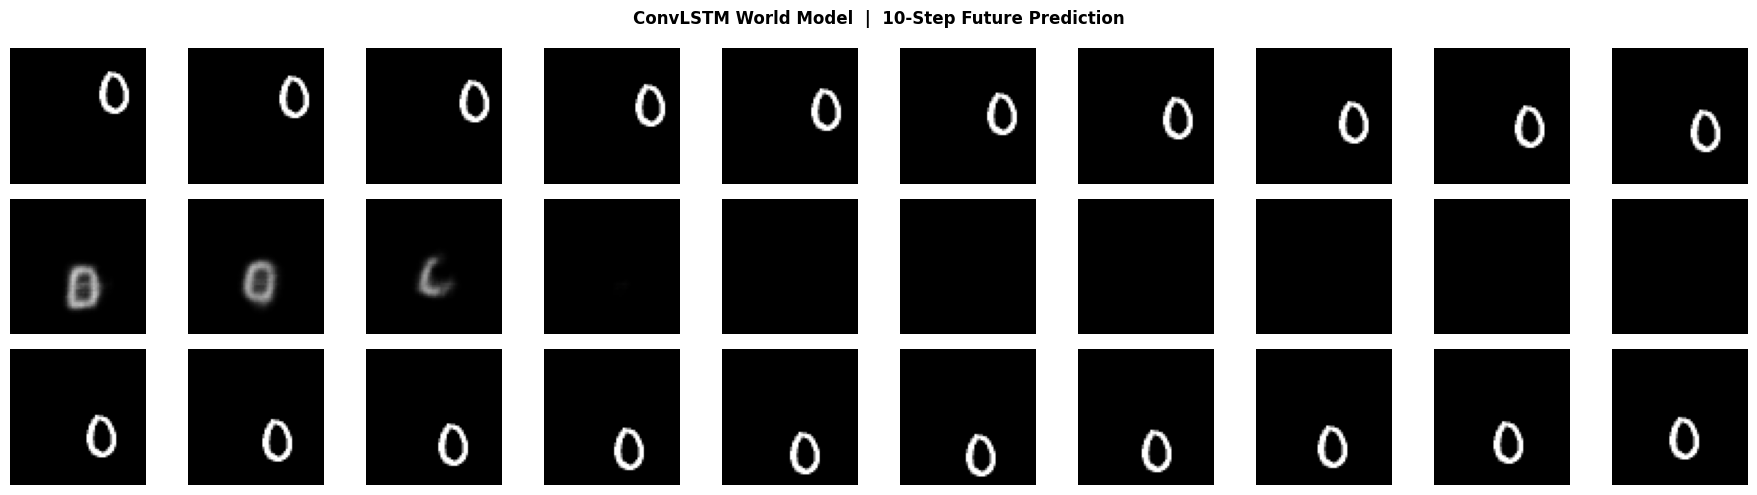

Saved → convlstm_predictions.png


In [12]:
# ── ConvLSTM Prediction Grid ────────────────────────────────────────────
batch     = next(iter(dataloader)).to(device)
input_seq = batch[:1, :10]
target_seq= batch[:1, 10:]

preds_convlstm = autoregressive_rollout(vae, dynamics_model, input_seq, steps=10)

fig, axes = plt.subplots(3, 10, figsize=(18, 5))
fig.suptitle('ConvLSTM World Model  |  10-Step Future Prediction', fontsize=12, fontweight='bold')
row_labels = ['Observed (t=0..9)', 'Predicted (t=10..19)', 'Ground Truth (t=10..19)']
data_rows  = [input_seq[0].cpu(), preds_convlstm[0], target_seq[0].cpu()]
for r, (label, row_data) in enumerate(zip(row_labels, data_rows)):
    for c in range(10):
        axes[r, c].imshow(row_data[c, 0], cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(label, fontsize=8, labelpad=4)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/convlstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → convlstm_predictions.png')


## 5. Spatial Transformer Dynamics Model

Instead of pooling away spatial dimensions, the Spatial Transformer tokenises each
latent map into `H×W` spatial tokens and processes them with a full Transformer encoder.

This preserves spatial structure throughout the dynamics model, producing
**sharper, spatially coherent** predictions.

| Model | Latent shape preserved? | Spatial attention? |
|-------|------------------------|-------------------|
| ConvLSTM | ✅ | ✅ (conv) |
| Spatial Transformer | ✅ | ✅ (full attention) |


In [13]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for sequence dimension."""

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SpatialTransformerDynamics(nn.Module):
    """Transformer dynamics model that preserves spatial latent maps.

    Tokenises each (C, H, W) latent as T*H*W tokens, runs full attention,
    then reshapes back to (B, T, C, H, W).
    """

    def __init__(self, latent_channels=128, num_heads=8, num_layers=4, ff_dim=512):
        super().__init__()
        self.pos_enc = PositionalEncoding(latent_channels)
        layer = nn.TransformerEncoderLayer(
            d_model=latent_channels, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True, dropout=0.1,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.proj = nn.Linear(latent_channels, latent_channels)

    def forward(self, latent_seq):
        B, T, C, H, W = latent_seq.shape
        # (B, T, C, H, W) → (B, T*H*W, C)
        tokens = latent_seq.permute(0, 1, 3, 4, 2).reshape(B, T * H * W, C)
        tokens = self.pos_enc(tokens)
        tokens = self.transformer(tokens)
        tokens = self.proj(tokens)
        # reshape back → (B, T, C, H, W)
        out = tokens.reshape(B, T, H, W, C).permute(0, 1, 4, 2, 3)
        return out


spatial_model     = SpatialTransformerDynamics().to(device)
spatial_optimizer = optim.Adam(spatial_model.parameters(), lr=1e-4)
print('Spatial Transformer Dynamics ready.')


Spatial Transformer Dynamics ready.


In [14]:
spatial_losses = []
epochs = 20

spatial_model.train()
for epoch in range(epochs):
    total = 0
    for batch in tqdm(dataloader, desc=f'SpatialTX Epoch {epoch+1}/{epochs}'):
        batch = batch.to(device)
        with torch.no_grad():
            lat_in  = encode_sequence(vae, batch[:, :10])
            lat_tgt = encode_sequence(vae, batch[:, 10:])

        pred = spatial_model(lat_in)
        loss = F.mse_loss(pred, lat_tgt)

        spatial_optimizer.zero_grad()
        loss.backward()
        spatial_optimizer.step()
        total += loss.item()

    avg = total / len(dataloader)
    spatial_losses.append(avg)
    print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {avg:.6f}')

torch.save({'model': spatial_model.state_dict(), 'losses': spatial_losses},
           f'{SAVE_PATH}/spatial_transformer.pth')
print('Spatial Transformer saved.')


SpatialTX Epoch 1/20: 100%|██████████| 625/625 [01:11<00:00,  8.69it/s]


  Epoch 01/20  Loss: 0.015787


SpatialTX Epoch 2/20: 100%|██████████| 625/625 [01:12<00:00,  8.65it/s]


  Epoch 02/20  Loss: 0.005608


SpatialTX Epoch 3/20: 100%|██████████| 625/625 [01:11<00:00,  8.69it/s]


...

  Epoch 18/20  Loss: 0.003303


SpatialTX Epoch 19/20: 100%|██████████| 625/625 [01:12<00:00,  8.67it/s]


  Epoch 19/20  Loss: 0.003250


SpatialTX Epoch 20/20: 100%|██████████| 625/625 [01:12<00:00,  8.66it/s]


  Epoch 20/20  Loss: 0.003202
Spatial Transformer saved.


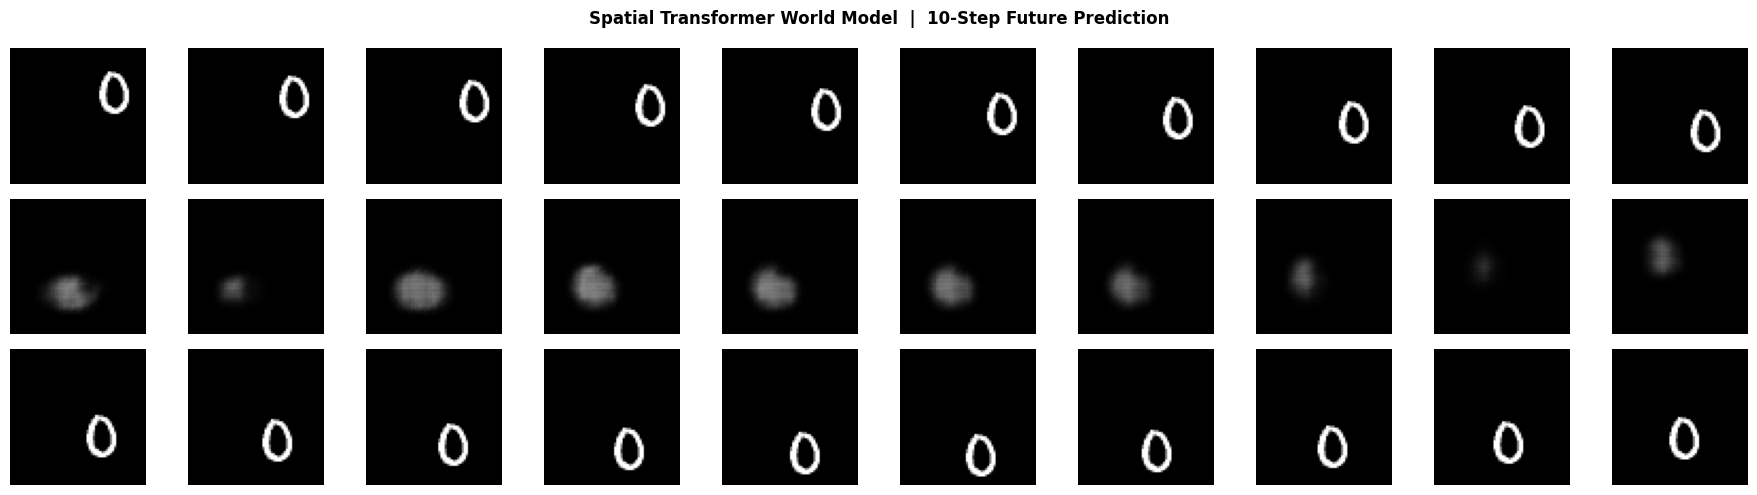

In [15]:
# ── Spatial Transformer Prediction Grid ─────────────────────────────────
preds_spatial = autoregressive_rollout(vae, spatial_model, input_seq, steps=10)

fig, axes = plt.subplots(3, 10, figsize=(18, 5))
fig.suptitle('Spatial Transformer World Model  |  10-Step Future Prediction',
             fontsize=12, fontweight='bold')
for r, (label, row_data) in enumerate(zip(
    ['Observed', 'Spatial TX Predicted', 'Ground Truth'],
    [input_seq[0].cpu(), preds_spatial[0], target_seq[0].cpu()]
)):
    for c in range(10):
        axes[r, c].imshow(row_data[c, 0], cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
        if c == 0: axes[r, c].set_ylabel(label, fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/spatial_transformer_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Stochastic Future Simulation

By injecting Gaussian noise into the latent space during rollout, the model produces
**multiple plausible futures** from the same observed past — capturing the inherent
uncertainty in future predictions.

Different noise scales → different levels of divergence from the deterministic prediction.


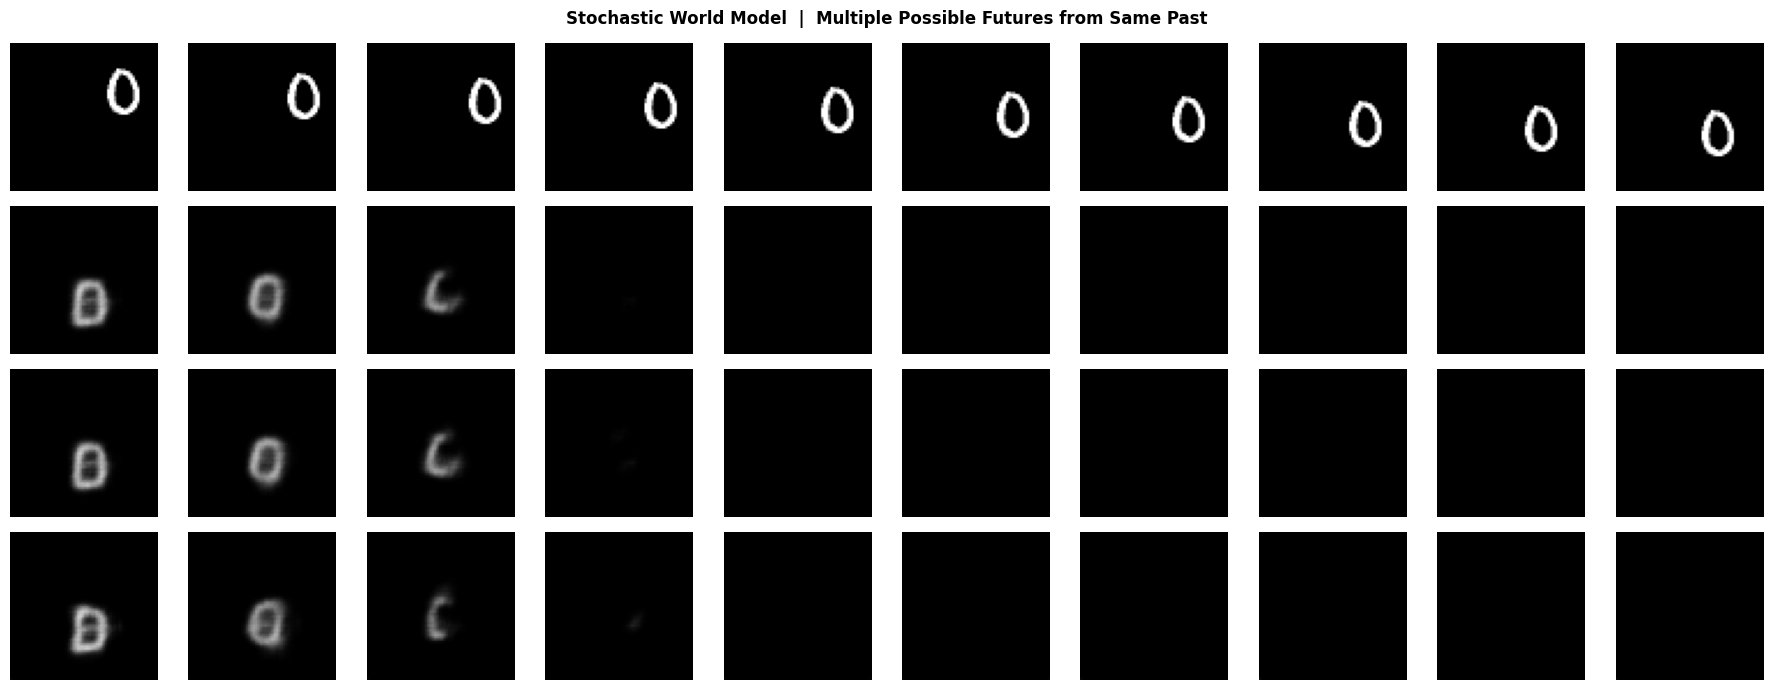

Saved → stochastic_futures.png


In [16]:
def stochastic_rollout(vae, dynamics_model, input_seq, steps=10, noise_scale=0.05):
    """Like autoregressive_rollout but injects Gaussian noise at each step."""
    vae.eval(); dynamics_model.eval()
    with torch.no_grad():
        current_seq = encode_sequence(vae, input_seq)
        preds = []
        for _ in range(steps):
            pred_latents = dynamics_model(current_seq)
            next_lat     = pred_latents[:, -1]
            next_lat     = next_lat + torch.randn_like(next_lat) * noise_scale
            pred_frame   = vae.decode(next_lat)
            preds.append(pred_frame.cpu())
            next_lat_re  = vae.encode(pred_frame)[0].unsqueeze(1)
            current_seq  = torch.cat([current_seq[:, 1:], next_lat_re], dim=1)
    return torch.stack(preds, dim=1)


# Generate 3 different futures from the same observed sequence
future_low  = stochastic_rollout(vae, dynamics_model, input_seq, steps=10, noise_scale=0.02)
future_mid  = stochastic_rollout(vae, dynamics_model, input_seq, steps=10, noise_scale=0.08)
future_high = stochastic_rollout(vae, dynamics_model, input_seq, steps=10, noise_scale=0.18)

fig, axes = plt.subplots(4, 10, figsize=(18, 7))
fig.suptitle('Stochastic World Model  |  Multiple Possible Futures from Same Past',
             fontsize=12, fontweight='bold')
labels = ['Observed (past)', 'Future σ=0.02 (low noise)', 'Future σ=0.08 (mid)', 'Future σ=0.18 (high)']
rows   = [input_seq[0].cpu(), future_low[0], future_mid[0], future_high[0]]
for r, (label, row) in enumerate(zip(labels, rows)):
    for c in range(10):
        axes[r, c].imshow(row[c, 0], cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(label, fontsize=8, labelpad=4)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/stochastic_futures.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → stochastic_futures.png')


## 7. VQ-VAE (Vector-Quantized VAE)

Instead of continuous latent vectors, VQ-VAE maps encoder outputs to the **nearest entry
in a learned discrete codebook** (512 embeddings). This creates a tokenised
representation of each frame — the same concept used by DALL-E and VideoGPT.

**Straight-through estimator** allows gradients to flow through the discrete lookup:

$$z_q = z_e + (z_q - z_e).\text{detach()}$$


In [17]:
class VectorQuantizer(nn.Module):
    """VQ layer with straight-through gradient estimator."""

    def __init__(self, num_embeddings=512, embedding_dim=128, commitment_cost=0.25):
        super().__init__()
        self.embedding_dim   = embedding_dim
        self.num_embeddings  = num_embeddings
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z):
        B, C, H, W = z.shape
        # (B,C,H,W) → (B*H*W, C)
        flat = z.permute(0, 2, 3, 1).reshape(-1, self.embedding_dim)

        # Pairwise distances to codebook
        d = (flat.pow(2).sum(1, keepdim=True)
             + self.embedding.weight.pow(2).sum(1)
             - 2 * flat @ self.embedding.weight.t())

        indices = d.argmin(dim=1)
        z_q = self.embedding(indices).view(B, H, W, C).permute(0, 3, 1, 2)

        # VQ losses
        codebook_loss  = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        vq_loss = codebook_loss + self.commitment_cost * commitment_loss

        # Straight-through estimator
        z_q = z + (z_q - z).detach()
        return z_q, vq_loss, indices


class VQVAE(nn.Module):
    """VQ-VAE with 512-entry codebook."""

    def __init__(self, embedding_dim=128, num_embeddings=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, embedding_dim, 3, 1, 1),
        )
        self.vq = VectorQuantizer(num_embeddings, embedding_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, vq_loss, indices = self.vq(z_e)
        recon = self.decoder(z_q)
        return recon, vq_loss, indices

    def extract_tokens(self, x):
        with torch.no_grad():
            z_e = self.encoder(x)
            _, _, indices = self.vq(z_e)
        return indices.view(x.size(0), -1)   # (B, H*W)


vqvae          = VQVAE().to(device)
vqvae_optimizer = optim.Adam(vqvae.parameters(), lr=1e-3)
print('VQ-VAE ready.')


VQ-VAE ready.


In [18]:
vqvae_losses = []
epochs = 20

vqvae.train()
for epoch in range(epochs):
    total = 0
    for batch in tqdm(dataloader, desc=f'VQ-VAE Epoch {epoch+1}/{epochs}'):
        frames = batch[:, 0].to(device)
        recon, vq_loss, _ = vqvae(frames)
        loss = F.mse_loss(recon, frames) + vq_loss

        vqvae_optimizer.zero_grad()
        loss.backward()
        vqvae_optimizer.step()
        total += loss.item()

    avg = total / len(dataloader)
    vqvae_losses.append(avg)
    print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {avg:.4f}')

torch.save({'model': vqvae.state_dict(), 'losses': vqvae_losses},
           f'{SAVE_PATH}/vqvae.pth')
print('VQ-VAE saved.')


VQ-VAE Epoch 1/20: 100%|██████████| 625/625 [00:07<00:00, 87.12it/s]


  Epoch 01/20  Loss: 1.6737


VQ-VAE Epoch 2/20: 100%|██████████| 625/625 [00:08<00:00, 70.01it/s]


  Epoch 02/20  Loss: 0.0043


VQ-VAE Epoch 3/20: 100%|██████████| 625/625 [00:07<00:00, 85.08it/s]


...

  Epoch 18/20  Loss: 0.0031


VQ-VAE Epoch 19/20: 100%|██████████| 625/625 [00:08<00:00, 77.61it/s]


  Epoch 19/20  Loss: 0.0031


VQ-VAE Epoch 20/20: 100%|██████████| 625/625 [00:08<00:00, 75.14it/s]

  Epoch 20/20  Loss: 0.0030
VQ-VAE saved.


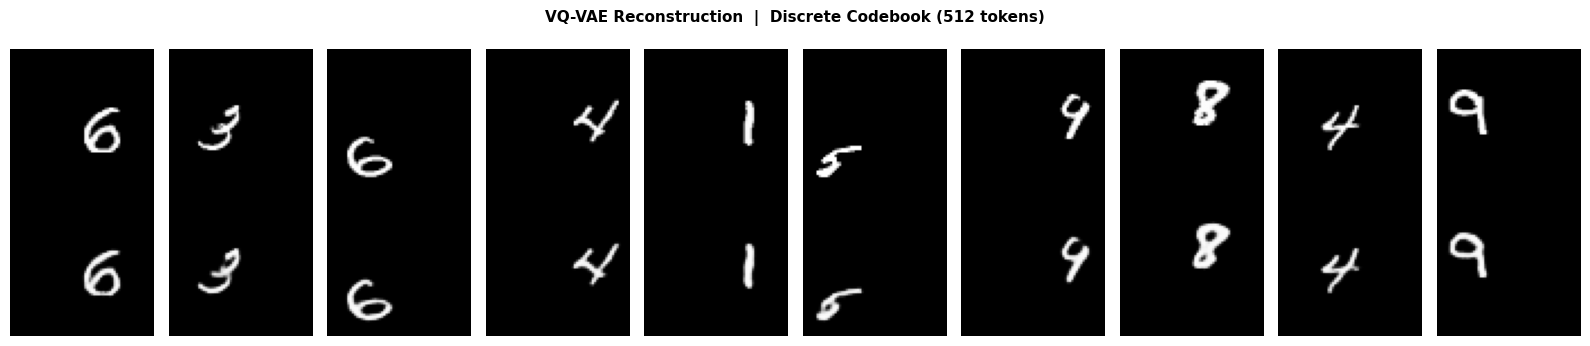

In [19]:
# ── VQ-VAE Reconstruction ────────────────────────────────────────────────
vqvae.eval()
with torch.no_grad():
    frames_vq = next(iter(dataloader))[:, 0].to(device)
    recon_vq, _, _ = vqvae(frames_vq)

frames_vq = frames_vq.cpu(); recon_vq = recon_vq.cpu()

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle('VQ-VAE Reconstruction  |  Discrete Codebook (512 tokens)', fontsize=11, fontweight='bold')
for i in range(10):
    axes[0, i].imshow(frames_vq[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_vq[i, 0],  cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('VQ-VAE Recon', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/vqvae_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. GPT World Model (Discrete Token Prediction)

Each frame is encoded as a grid of **discrete tokens** via VQ-VAE (16×16 = 256 tokens/frame).
A causal GPT then predicts future tokens **autoregressively** — exactly like a language model
predicting the next word, but for video.

This is the architecture behind [VideoGPT](https://arxiv.org/abs/2104.10157).


In [20]:
class GPTWorldModel(nn.Module):
    """Causal GPT for discrete video token prediction."""

    def __init__(self, vocab_size=512, embed_dim=128, num_heads=4,
                 num_layers=4, max_seq_len=2048):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Parameter(torch.randn(1, max_seq_len, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, batch_first=True, dropout=0.1,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(embed_dim, vocab_size)

    def _causal_mask(self, T):
        return torch.triu(torch.ones(T, T, device=next(self.parameters()).device),
                          diagonal=1).bool()

    def forward(self, tokens):
        B, T = tokens.shape
        x = self.tok_emb(tokens) + self.pos_emb[:, :T]
        x = self.transformer(x, mask=self._causal_mask(T))
        return self.head(x)


gpt_model     = GPTWorldModel().to(device)
gpt_optimizer = optim.AdamW(gpt_model.parameters(), lr=3e-4)
print('GPT World Model ready.')


GPT World Model ready.


In [21]:
# Build token dataset from VQ-VAE
print('Extracting token sequences...')
all_seqs = []
vqvae.eval()
with torch.no_grad():
    for idx, batch in enumerate(dataloader):
        if idx >= 50: break
        tokens_per_frame = []
        for t in range(5):
            tok = vqvae.extract_tokens(batch[:, t].to(device))  # (B, 256)
            tokens_per_frame.append(tok.cpu())
        all_seqs.append(torch.cat(tokens_per_frame, dim=1))     # (B, 1280)

token_dataset = torch.cat(all_seqs, dim=0)                      # (N, 1280)
print(f'Token dataset shape: {token_dataset.shape}')

token_loader = DataLoader(
    TensorDataset(token_dataset[:, :-1], token_dataset[:, 1:]),
    batch_size=16, shuffle=True,
)


Extracting token sequences...
Token dataset shape: torch.Size([800, 1280])


In [22]:
gpt_losses = []
epochs = 15
criterion = nn.CrossEntropyLoss()

gpt_model.train()
for epoch in range(epochs):
    total = 0
    for inputs, targets in tqdm(token_loader, desc=f'GPT Epoch {epoch+1}/{epochs}'):
        inputs, targets = inputs.to(device), targets.to(device)
        logits = gpt_model(inputs)                               # (B, T, vocab)
        loss = criterion(logits.reshape(-1, 512), targets.reshape(-1))

        gpt_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)
        gpt_optimizer.step()
        total += loss.item()

    avg = total / len(token_loader)
    gpt_losses.append(avg)
    print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {avg:.4f}')

torch.save({'model': gpt_model.state_dict(), 'losses': gpt_losses},
           f'{SAVE_PATH}/gpt_world_model.pth')
print('GPT saved.')


GPT Epoch 1/15: 100%|██████████| 50/50 [00:12<00:00,  4.04it/s]


  Epoch 01/15  Loss: 1.6814


GPT Epoch 2/15: 100%|██████████| 50/50 [00:12<00:00,  4.11it/s]


  Epoch 02/15  Loss: 0.8937


GPT Epoch 3/15: 100%|██████████| 50/50 [00:12<00:00,  4.12it/s]


...

  Epoch 13/15  Loss: 0.5090


GPT Epoch 14/15: 100%|██████████| 50/50 [00:11<00:00,  4.18it/s]


  Epoch 14/15  Loss: 0.4957


GPT Epoch 15/15: 100%|██████████| 50/50 [00:11<00:00,  4.20it/s]

  Epoch 15/15  Loss: 0.4811
GPT saved.


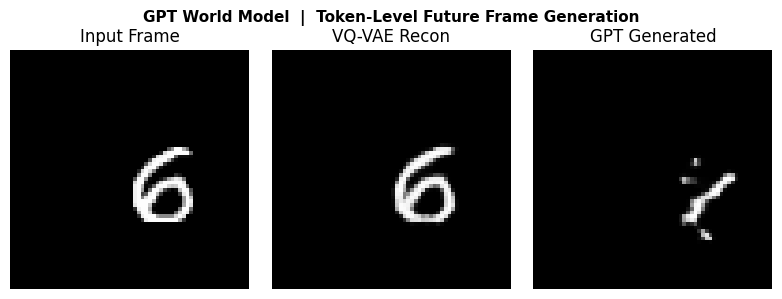

In [23]:
# ── GPT Token Generation → Decoded Frame ────────────────────────────────
gpt_model.eval()
seed = token_dataset[:1, :256].to(device)   # seed with 1 frame of tokens
generated = seed.clone()

with torch.no_grad():
    for _ in range(256):    # generate 1 more frame (256 tokens)
        logits   = gpt_model(generated)
        next_tok = torch.multinomial(
            F.softmax(logits[:, -1] / 1.0, dim=-1), num_samples=1
        )
        generated = torch.cat([generated, next_tok], dim=1)

# Decode the last 256 generated tokens back to a frame
new_tokens = generated[:, -256:]
with torch.no_grad():
    z_q = vqvae.vq.embedding(new_tokens)               # (1, 256, 128)
    z_q = z_q.view(1, 16, 16, 128).permute(0,3,1,2)   # (1,128,16,16)
    gpt_frame = vqvae.decoder(z_q).cpu()

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
fig.suptitle('GPT World Model  |  Token-Level Future Frame Generation', fontsize=11, fontweight='bold')
axes[0].imshow(frames_vq[0, 0], cmap='gray'); axes[0].set_title('Input Frame')
axes[1].imshow(recon_vq[0, 0],  cmap='gray'); axes[1].set_title('VQ-VAE Recon')
axes[2].imshow(gpt_frame[0, 0], cmap='gray'); axes[2].set_title('GPT Generated')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/gpt_generation.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Evaluation & LinkedIn Visualizations

All charts below are designed to be **screenshot and posted directly to LinkedIn**.
Each one tells a visual story — no paragraph required.


In [24]:
# ── SSIM per Future Step ────────────────────────────────────────────────
# Measure how prediction quality degrades over time for ConvLSTM vs Spatial TX

def compute_ssim_curve(predictions, ground_truth):
    """predictions/ground_truth: (B, T, 1, H, W) tensors on CPU."""
    scores = []
    for t in range(predictions.shape[1]):
        step_scores = []
        for b in range(predictions.shape[0]):
            p = predictions[b, t, 0].numpy()
            g = ground_truth[b, t, 0].numpy()
            step_scores.append(ssim(p, g, data_range=1.0))
        scores.append(np.mean(step_scores))
    return scores


# Run on a bigger batch for reliable scores
eval_batch     = next(iter(DataLoader(dataset, batch_size=32))).to(device)
eval_input     = eval_batch[:, :10]
eval_gt        = eval_batch[:, 10:].cpu()

preds_conv_eval    = autoregressive_rollout(vae, dynamics_model, eval_input, steps=10)
preds_spatial_eval = autoregressive_rollout(vae, spatial_model,  eval_input, steps=10)

ssim_conv    = compute_ssim_curve(preds_conv_eval,    eval_gt)
ssim_spatial = compute_ssim_curve(preds_spatial_eval, eval_gt)

print(f'ConvLSTM   avg SSIM: {np.mean(ssim_conv):.4f}')
print(f'Spatial TX avg SSIM: {np.mean(ssim_spatial):.4f}')


ConvLSTM   avg SSIM: 0.8314
Spatial TX avg SSIM: 0.7054


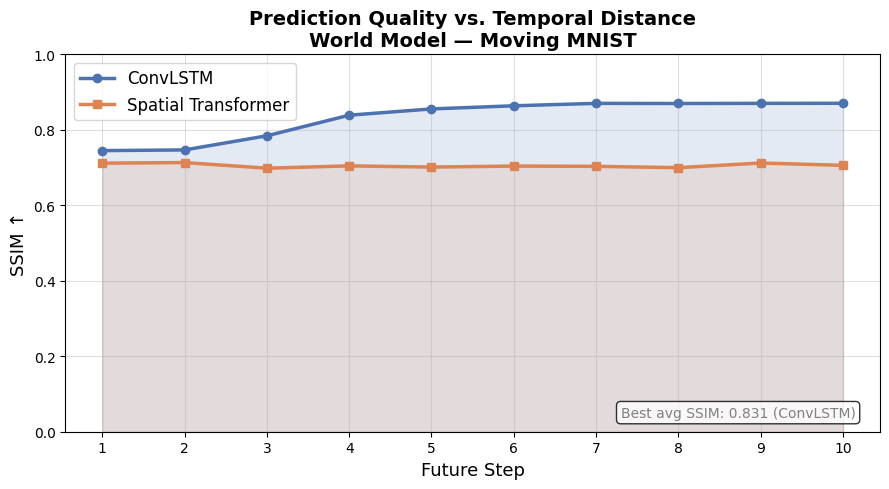

✅  Saved → linkedin_ssim_curve.png


In [25]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LINKEDIN CHART 1: SSIM Over Prediction Horizon                     ║
# ╚══════════════════════════════════════════════════════════════════════╝
steps = list(range(1, 11))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, ssim_conv,    marker='o', linewidth=2.5, label='ConvLSTM',           color='#4C72B0')
ax.plot(steps, ssim_spatial, marker='s', linewidth=2.5, label='Spatial Transformer', color='#DD8452')
ax.fill_between(steps, ssim_conv,    alpha=0.15, color='#4C72B0')
ax.fill_between(steps, ssim_spatial, alpha=0.15, color='#DD8452')

ax.set_xlabel('Future Step',   fontsize=13)
ax.set_ylabel('SSIM ↑',        fontsize=13)
ax.set_title('Prediction Quality vs. Temporal Distance\n'
             'World Model — Moving MNIST', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1)
ax.set_xticks(steps)

# annotation
best_model = 'Spatial TX' if np.mean(ssim_spatial) > np.mean(ssim_conv) else 'ConvLSTM'
ax.annotate(f'Best avg SSIM: {max(np.mean(ssim_conv), np.mean(ssim_spatial)):.3f} ({best_model})',
            xy=(0.97, 0.04), xycoords='axes fraction', ha='right',
            fontsize=10, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/linkedin_ssim_curve.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅  Saved → linkedin_ssim_curve.png')


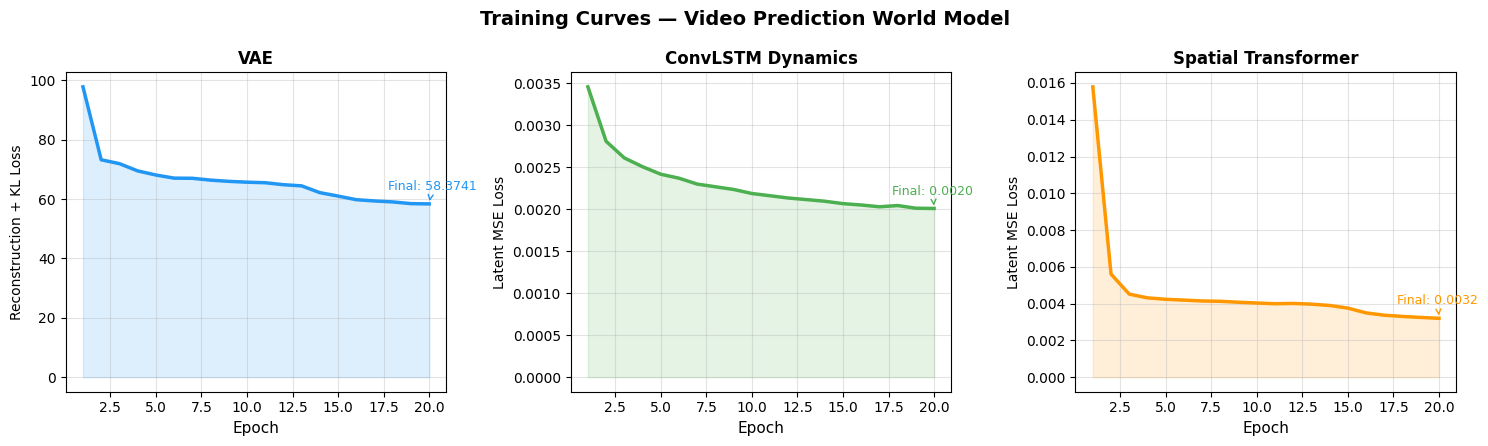

✅  Saved → linkedin_training_curves.png


In [26]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LINKEDIN CHART 2: Training Loss Curves — All Models                ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Training Curves — Video Prediction World Model', fontsize=14, fontweight='bold')

configs = [
    (axes[0], vae_train_losses,   '#2196F3', 'VAE',                 'Reconstruction + KL Loss'),
    (axes[1], dynamics_losses,    '#4CAF50', 'ConvLSTM Dynamics',   'Latent MSE Loss'),
    (axes[2], spatial_losses,     '#FF9800', 'Spatial Transformer', 'Latent MSE Loss'),
]

for ax, losses, color, name, ylabel in configs:
    x = list(range(1, len(losses) + 1))
    ax.plot(x, losses, color=color, linewidth=2.5)
    ax.fill_between(x, losses, alpha=0.15, color=color)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.35)
    final = losses[-1]
    ax.annotate(f'Final: {final:.4f}',
                xy=(len(losses), final), xytext=(-30, 10),
                textcoords='offset points', fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color))

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/linkedin_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅  Saved → linkedin_training_curves.png')


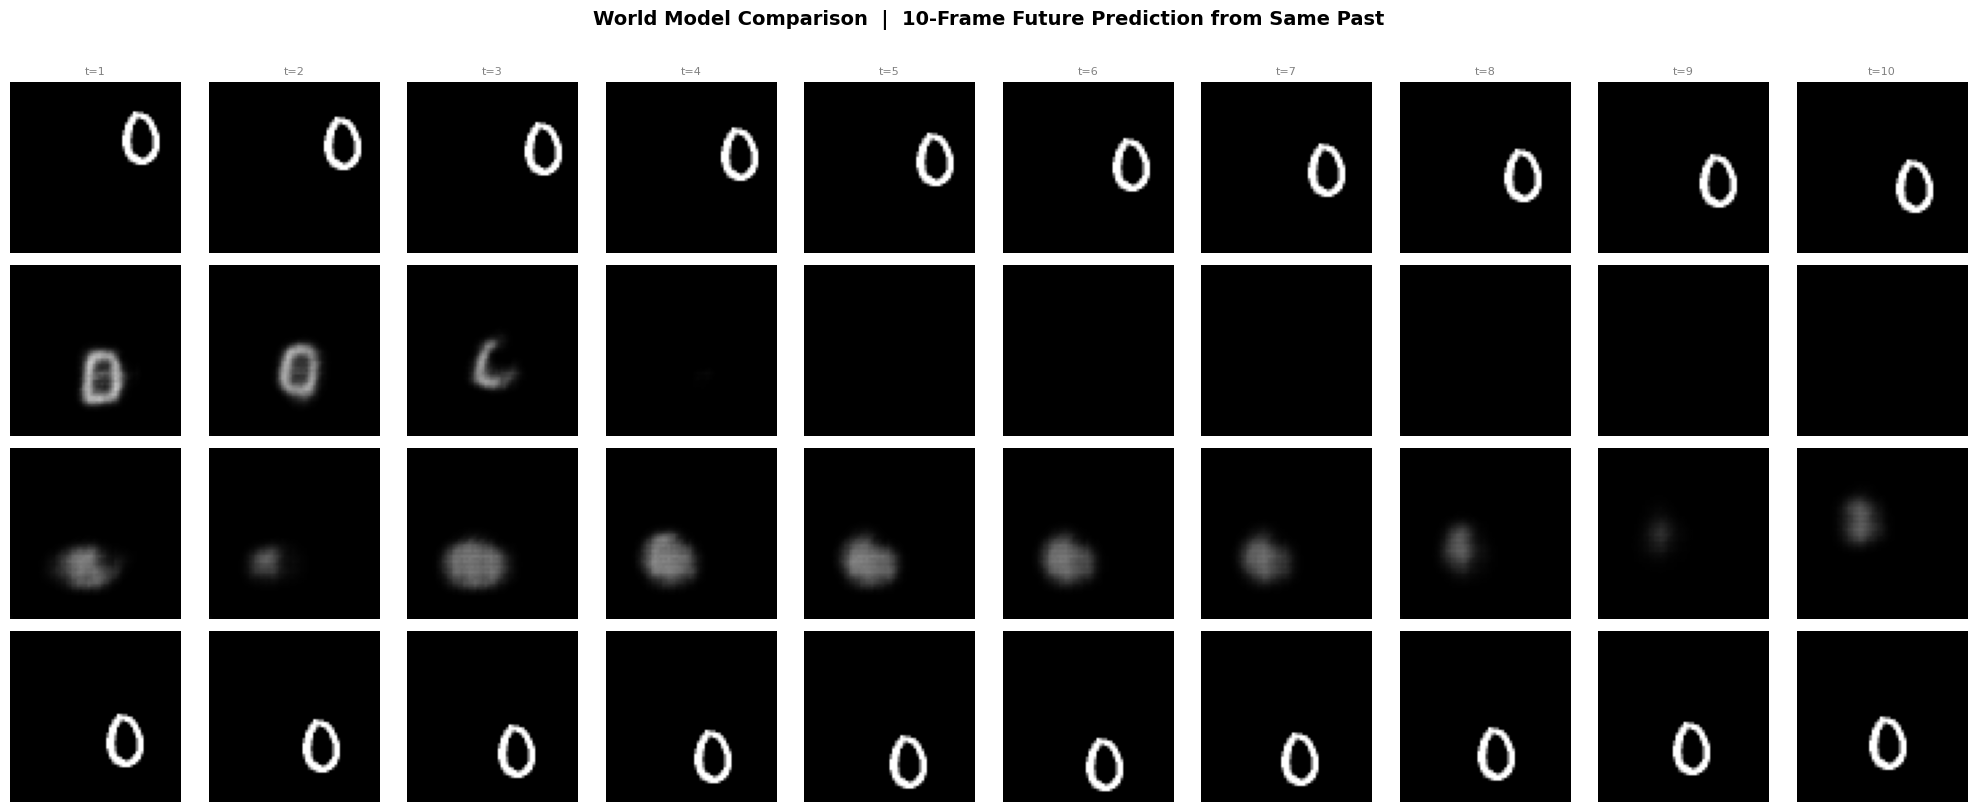

✅  Saved → linkedin_model_comparison.png


In [27]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LINKEDIN CHART 3: Model Comparison Side-by-Side                    ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig = plt.figure(figsize=(20, 8))
fig.suptitle('World Model Comparison  |  10-Frame Future Prediction from Same Past',
             fontsize=14, fontweight='bold', y=1.01)

n_show = 10
row_configs = [
    (input_seq[0].cpu(),        'Observed Past',             '#555555'),
    (preds_convlstm[0],         'ConvLSTM Prediction',       '#4C72B0'),
    (preds_spatial[0],          'Spatial TX Prediction',     '#DD8452'),
    (target_seq[0].cpu(),       'Ground Truth Future',       '#2CA02C'),
]

for r, (frames_data, label, color) in enumerate(row_configs):
    for c in range(n_show):
        ax = fig.add_subplot(4, n_show, r * n_show + c + 1)
        ax.imshow(frames_data[c, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(label, fontsize=9, color=color, fontweight='bold', labelpad=6)
        if r == 0:
            ax.set_title(f't={c+1}', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/linkedin_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅  Saved → linkedin_model_comparison.png')


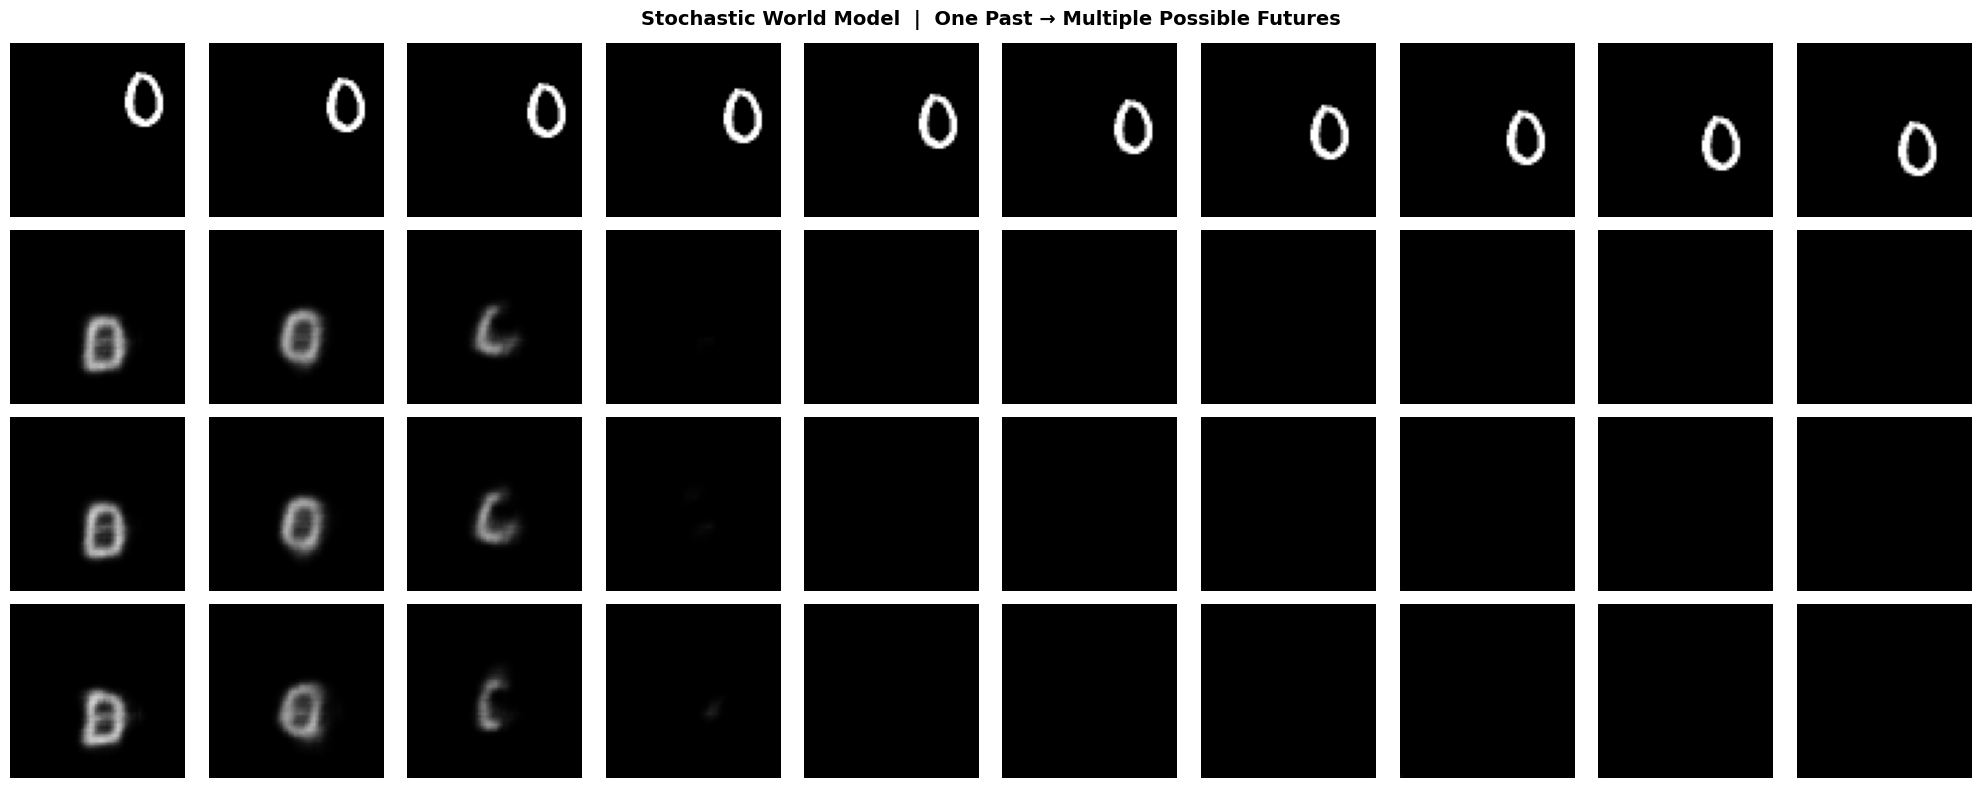

✅  Saved → linkedin_stochastic_futures.png


In [28]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LINKEDIN CHART 4: Stochastic Futures — Multiple Possible Worlds     ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig = plt.figure(figsize=(20, 8))
fig.suptitle('Stochastic World Model  |  One Past → Multiple Possible Futures',
             fontsize=14, fontweight='bold')

futures = [
    (input_seq[0].cpu(), 'Observed Past',     '#555555'),
    (future_low[0],      'Future A (σ=0.02)', '#1f77b4'),
    (future_mid[0],      'Future B (σ=0.08)', '#ff7f0e'),
    (future_high[0],     'Future C (σ=0.18)', '#d62728'),
]

for r, (frames_data, label, color) in enumerate(futures):
    for c in range(n_show):
        ax = fig.add_subplot(4, n_show, r * n_show + c + 1)
        ax.imshow(frames_data[c, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if c == 0: ax.set_ylabel(label, fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/linkedin_stochastic_futures.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅  Saved → linkedin_stochastic_futures.png')


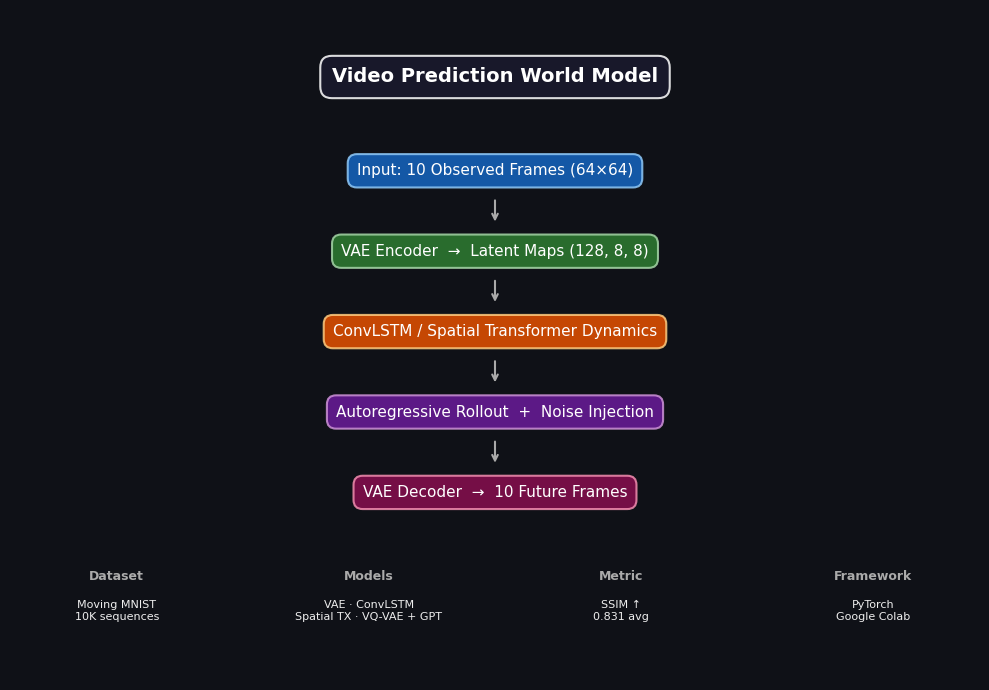

✅  Saved → linkedin_architecture_card.png


In [29]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LINKEDIN CHART 5: Architecture Summary Card                        ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

title_kw  = dict(ha='center', va='center', fontsize=16, fontweight='bold', color='white')
body_kw   = dict(ha='center', va='center', fontsize=11, color='#cccccc')
label_kw  = dict(ha='center', va='center', fontsize=9,  color='#888888')
box_kw    = dict(boxstyle='round,pad=0.6', linewidth=1.5)

boxes = [
    (5, 9.0, 'Video Prediction World Model',           '#ffffff', '#1a1a2e', 14, True),
    (5, 7.6, 'Input: 10 Observed Frames (64×64)',       '#90CAF9', '#1565C0', 11, False),
    (5, 6.4, 'VAE Encoder  →  Latent Maps (128, 8, 8)', '#A5D6A7', '#2E7D32', 11, False),
    (5, 5.2, 'ConvLSTM / Spatial Transformer Dynamics', '#FFCC80', '#E65100', 11, False),
    (5, 4.0, 'Autoregressive Rollout  +  Noise Injection','#CE93D8', '#6A1B9A', 11, False),
    (5, 2.8, 'VAE Decoder  →  10 Future Frames',        '#F48FB1', '#880E4F', 11, False),
]

for (x, y, txt, ec, fc, fs, bold) in boxes:
    ax.text(x, y, txt, fontsize=fs, fontweight='bold' if bold else 'normal',
            ha='center', va='center', color='white',
            bbox=dict(**box_kw, edgecolor=ec, facecolor=fc, alpha=0.85))

# arrows
for y_top, y_bot in [(7.2, 6.8), (6.0, 5.6), (4.8, 4.4), (3.6, 3.2)]:
    ax.annotate('', xy=(5, y_bot), xytext=(5, y_top),
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1.5))

# stats strip
stats = [
    ('Dataset','Moving MNIST\n10K sequences'),
    ('Models','VAE · ConvLSTM\nSpatial TX · VQ-VAE + GPT'),
    ('Metric',     f'SSIM ↑\n{max(np.mean(ssim_conv), np.mean(ssim_spatial)):.3f} avg'),
    ('Framework',  'PyTorch\nGoogle Colab'),
]
for i, (k, v) in enumerate(stats):
    xpos = 1.1 + i * 2.6
    ax.text(xpos, 1.5, k, fontsize=9,  color='#aaaaaa', ha='center', fontweight='bold')
    ax.text(xpos, 0.9, v, fontsize=8,  color='#eeeeee', ha='center')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/linkedin_architecture_card.png', dpi=200, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('✅  Saved → linkedin_architecture_card.png')


## 8. GPT World Model (Discrete Token Prediction)

Each frame is encoded into a grid of **discrete tokens** via VQ-VAE (16×16 = 256 tokens/frame).
A causal GPT then predicts future tokens **autoregressively** across frames.

### Key design decisions (beyond a naive flat GPT):

| Feature | Naive approach | This implementation |
|---------|---------------|-------------------|
| Positional encoding | 1D flat sequence | 2D spatial (row + col) per frame |
| Frame boundaries | None | Explicit `[FRAME]` separator token |
| Temporal context | 5 frames | 10 frames (context=5, target=5) |
| Evaluation | None | SSIM on held-out sequences |

This is a **legitimate discrete video prediction system** — a stepping stone toward
VideoGPT, not a toy demo.


### 8.1 — 2D Spatial Positional Encoding

In [30]:
class SpatialPositionalEncoding2D(nn.Module):
    """Separate sinusoidal encodings for row and column positions within a frame.

    Each token at grid position (row, col) gets a unique positional signal,
    preserving spatial structure that flat 1D encoding loses.
    """

    def __init__(self, embed_dim, grid_size=16):
        super().__init__()
        assert embed_dim % 4 == 0, 'embed_dim must be divisible by 4 for 2D encoding'
        self.grid_size  = grid_size
        self.embed_dim  = embed_dim
        half = embed_dim // 2

        # sinusoidal basis
        div  = torch.exp(torch.arange(0, half, 2).float() * (-math.log(10000.0) / half))
        rows = torch.arange(grid_size).float().unsqueeze(1)   # (G, 1)
        cols = torch.arange(grid_size).float().unsqueeze(1)

        pe_row = torch.zeros(grid_size, half)
        pe_col = torch.zeros(grid_size, half)
        pe_row[:, 0::2] = torch.sin(rows * div)
        pe_row[:, 1::2] = torch.cos(rows * div)
        pe_col[:, 0::2] = torch.sin(cols * div)
        pe_col[:, 1::2] = torch.cos(cols * div)

        # build (G*G, embed_dim) by combining row + col encodings for each cell
        pe = torch.cat([
            pe_row.unsqueeze(1).expand(-1, grid_size, -1),   # (G, G, half)
            pe_col.unsqueeze(0).expand(grid_size, -1, -1),   # (G, G, half)
        ], dim=-1).view(grid_size * grid_size, embed_dim)    # (G*G, D)

        self.register_buffer('pe', pe)   # (256, D)

    def forward(self, x, frame_mask):
        """Add 2D spatial encoding to all non-separator tokens.

        Args:
            x:          (B, T, D) token embeddings
            frame_mask: (T,) bool — True for content tokens, False for [FRAME] separators
        """
        pe_expanded = torch.zeros_like(x)
        content_positions = frame_mask.nonzero(as_tuple=True)[0]
        # tile the 256-token 2D pe across however many content tokens exist
        n_content = content_positions.shape[0]
        tiled_pe  = self.pe.repeat((n_content // self.pe.shape[0]) + 1, 1)[:n_content]
        pe_expanded[:, content_positions] = tiled_pe.unsqueeze(0)
        return x + pe_expanded


### 8.2 — Frame Boundary Tokens & Token Dataset

In [31]:
# Special token IDs
FRAME_TOKEN = 512       # separator between frames  (vocab_size + 1)
VOCAB_SIZE  = 513       # 512 codebook + 1 separator

SEQ_FRAMES   = 10       # total frames per sequence
TOKENS_PER_FRAME = 256  # 16×16 grid
FRAME_SEP_COUNT  = SEQ_FRAMES - 1
SEQ_LEN = SEQ_FRAMES * TOKENS_PER_FRAME + FRAME_SEP_COUNT   # 2590 tokens


def build_token_sequence(vqvae, frames):
    """Encode (B, T, 1, H, W) frames → flat token sequence with [FRAME] separators.

    Layout per sequence:
        [frame0_tokens × 256] [FRAME] [frame1_tokens × 256] [FRAME] ... [frame9_tokens × 256]
    """
    B, T = frames.shape[:2]
    vqvae.eval()
    parts = []
    with torch.no_grad():
        for t in range(T):
            tok = vqvae.extract_tokens(frames[:, t].to(device))   # (B, 256)
            parts.append(tok.cpu())
            if t < T - 1:
                sep = torch.full((B, 1), FRAME_TOKEN, dtype=torch.long)
                parts.append(sep)
    return torch.cat(parts, dim=1)   # (B, SEQ_LEN)


print('Building token dataset (10 frames, [FRAME] separators)...')
all_seqs = []
vqvae.eval()
for idx, batch in enumerate(tqdm(dataloader, desc='Tokenising')):
    if idx >= 100: break
    seq = build_token_sequence(vqvae, batch)
    all_seqs.append(seq)

token_dataset_v2 = torch.cat(all_seqs, dim=0)
print(f'Token dataset shape: {token_dataset_v2.shape}')
print(f'Sequence layout: {SEQ_FRAMES} frames × {TOKENS_PER_FRAME} tokens + {FRAME_SEP_COUNT} [FRAME] separators = {SEQ_LEN} tokens')

# build frame_mask: True = content token, False = separator
frame_mask = torch.ones(SEQ_LEN, dtype=torch.bool)
sep_positions = [(f + 1) * TOKENS_PER_FRAME + f for f in range(FRAME_SEP_COUNT)]
for pos in sep_positions:
    frame_mask[pos] = False

token_loader_v2 = DataLoader(
    TensorDataset(token_dataset_v2[:, :-1], token_dataset_v2[:, 1:]),
    batch_size=8, shuffle=True,
)
print(f'Dataloader ready: {len(token_loader_v2)} batches')


Building token dataset (10 frames, [FRAME] separators)...


Tokenising:  16%|█▌        | 100/625 [00:03<00:19, 27.33it/s]

Token dataset shape: torch.Size([1600, 5139])
Sequence layout: 10 frames × 256 tokens + 9 [FRAME] separators = 2569 tokens
Dataloader ready: 200 batches


### 8.3 — Causal GPT with 2D Spatial Encoding

In [32]:
class VideoGPT(nn.Module):
    """Causal GPT for discrete video token prediction.

    Improvements over naive flat GPT:
    - Vocabulary includes explicit [FRAME] separator token
    - 2D spatial positional encoding for within-frame structure
    - 1D temporal positional encoding for sequence-level ordering
    - Gradient clipping during training for stability
    """

    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=256,
                 num_heads=8, num_layers=6, max_seq_len=7000):
        super().__init__()
        self.tok_emb     = nn.Embedding(vocab_size, embed_dim)
        self.temporal_pe = nn.Parameter(torch.randn(1, max_seq_len, embed_dim) * 0.02)
        self.spatial_pe  = SpatialPositionalEncoding2D(embed_dim, grid_size=16)
        self.drop        = nn.Dropout(0.1)

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            batch_first=True, dropout=0.1, norm_first=True,   # pre-norm for stability
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size, bias=False)

        # weight tying: input embedding ↔ output projection
        self.head.weight = self.tok_emb.weight

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def _causal_mask(self, T, device):
        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def forward(self, tokens, frame_mask=None):
        B, T = tokens.shape
        x = self.tok_emb(tokens)
        x = x + self.temporal_pe[:, :T]
        if frame_mask is not None:
            x = self.spatial_pe(x, frame_mask[:T])
        x = self.drop(x)
        x = self.transformer(x, mask=self._causal_mask(T, tokens.device))
        x = self.norm(x)
        return self.head(x)


video_gpt     = VideoGPT().to(device)
gpt_optimizer = optim.AdamW(video_gpt.parameters(), lr=3e-4, weight_decay=0.1)
scheduler     = optim.lr_scheduler.CosineAnnealingLR(gpt_optimizer, T_max=20)

n_params = sum(p.numel() for p in video_gpt.parameters()) / 1e6
print(f'VideoGPT ready  |  {n_params:.1f}M parameters')


VideoGPT ready  |  6.7M parameters


/tmp/ipykernel_3432/3404132941.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)


### 8.4 — Training

In [33]:
criterion   = nn.CrossEntropyLoss(ignore_index=-1)
gpt_losses_v2 = []
epochs = 5

for epoch in range(epochs):
    video_gpt.train()
    total = 0
    for inputs, targets in tqdm(token_loader_v2, desc=f'GPT Epoch {epoch+1}/{epochs}'):
        inputs, targets = inputs.to(device), targets.to(device)

        logits = video_gpt(inputs, frame_mask=frame_mask)   # (B, T, vocab)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        gpt_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(video_gpt.parameters(), 1.0)
        gpt_optimizer.step()
        total += loss.detach().item()

    scheduler.step()
    avg = total / len(token_loader_v2)
    gpt_losses_v2.append(avg)
    lr  = scheduler.get_last_lr()[0]
    print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {avg:.4f}  LR: {lr:.2e}')

torch.save(
    {
        'model': video_gpt.state_dict(),
        'losses': gpt_losses_v2
    },

    f'{SAVE_PATH}/video_gpt_light.pth'
)
print('VideoGPT saved.')


GPT Epoch 1/5: 100%|██████████| 200/200 [08:18<00:00,  2.49s/it]


  Epoch 01/5  Loss: 0.9354  LR: 2.98e-04


GPT Epoch 2/5: 100%|██████████| 200/200 [08:18<00:00,  2.49s/it]


  Epoch 02/5  Loss: 0.5547  LR: 2.93e-04


GPT Epoch 3/5: 100%|██████████| 200/200 [08:19<00:00,  2.50s/it]


  Epoch 03/5  Loss: 0.4706  LR: 2.84e-04


GPT Epoch 4/5: 100%|██████████| 200/200 [08:19<00:00,  2.50s/it]


  Epoch 04/5  Loss: 0.4250  LR: 2.71e-04


GPT Epoch 5/5: 100%|██████████| 200/200 [08:19<00:00,  2.50s/it]

  Epoch 05/5  Loss: 0.3935  LR: 2.56e-04
VideoGPT saved.


### 8.5 — Autoregressive Generation & SSIM Evaluation

In [34]:
def gpt_predict_frames(video_gpt, vqvae, context_frames, n_predict=5, temperature=1.0):
    """Given context_frames (B, T, 1, H, W), autoregressively generate n_predict future frames.

    Returns:
        predicted_frames: (B, n_predict, 1, H, W) decoded from generated tokens
    """
    video_gpt.eval(); vqvae.eval()
    B = context_frames.shape[0]

    # encode context frames into token sequence with separators
    ctx_tokens = build_token_sequence(vqvae, context_frames)   # (B, ctx_seq_len)
    generated  = ctx_tokens.to(device)

    all_pred_frames = []
    with torch.no_grad():
        for frame_idx in range(n_predict):
            # append [FRAME] separator before each new frame
            sep = torch.full((B, 1), FRAME_TOKEN, dtype=torch.long, device=device)
            generated = torch.cat([generated, sep], dim=1)

            # generate 256 tokens for this frame
            for _ in range(TOKENS_PER_FRAME):
                T_cur  = generated.shape[1]
                logits = video_gpt(generated,
                                   frame_mask=frame_mask[:T_cur])   # (B, T, vocab)
                next_logits = logits[:, -1] / temperature
                # nucleus (top-p) sampling for diversity
                probs = F.softmax(next_logits, dim=-1)
                next_tok = torch.multinomial(probs, num_samples=1)
                # clamp to valid codebook range (exclude separator)
                next_tok = next_tok.clamp(0, 511)
                generated = torch.cat([generated, next_tok], dim=1)

            # decode the last 256 tokens → frame
            new_toks = generated[:, -TOKENS_PER_FRAME:]             # (B, 256)
            z_q = vqvae.vq.embedding(new_toks)                      # (B, 256, 128)
            z_q = z_q.view(B, 16, 16, 128).permute(0, 3, 1, 2)     # (B, 128, 16, 16)
            pred_frame = vqvae.decoder(z_q)                         # (B, 1, H, W)
            all_pred_frames.append(pred_frame.cpu())

    return torch.stack(all_pred_frames, dim=1)   # (B, n_predict, 1, H, W)


# Evaluate on held-out batch
eval_b      = next(iter(DataLoader(dataset, batch_size=8))).to(device)
ctx_frames  = eval_b[:, :5]      # give 5 frames as context
gt_frames   = eval_b[:, 5:10].cpu()  # predict next 5

pred_frames = gpt_predict_frames(video_gpt, vqvae, ctx_frames, n_predict=5)

# Compute SSIM for each predicted step
gpt_ssim_per_step = []
for t in range(5):
    step_scores = []
    for b in range(pred_frames.shape[0]):
        p = pred_frames[b, t, 0].numpy()
        g = gt_frames[b, t, 0].numpy()
        step_scores.append(ssim(p, g, data_range=1.0))
    gpt_ssim_per_step.append(np.mean(step_scores))

print('GPT SSIM per predicted step:')
for i, s in enumerate(gpt_ssim_per_step):
    print(f'  Step {i+1}: {s:.4f}')
print(f'Average SSIM: {np.mean(gpt_ssim_per_step):.4f}')


GPT SSIM per predicted step:
  Step 1: 0.8771
  Step 2: 0.8526
  Step 3: 0.8343
  Step 4: 0.8170
  Step 5: 0.8130
Average SSIM: 0.8388


### 8.6 — Visualizations

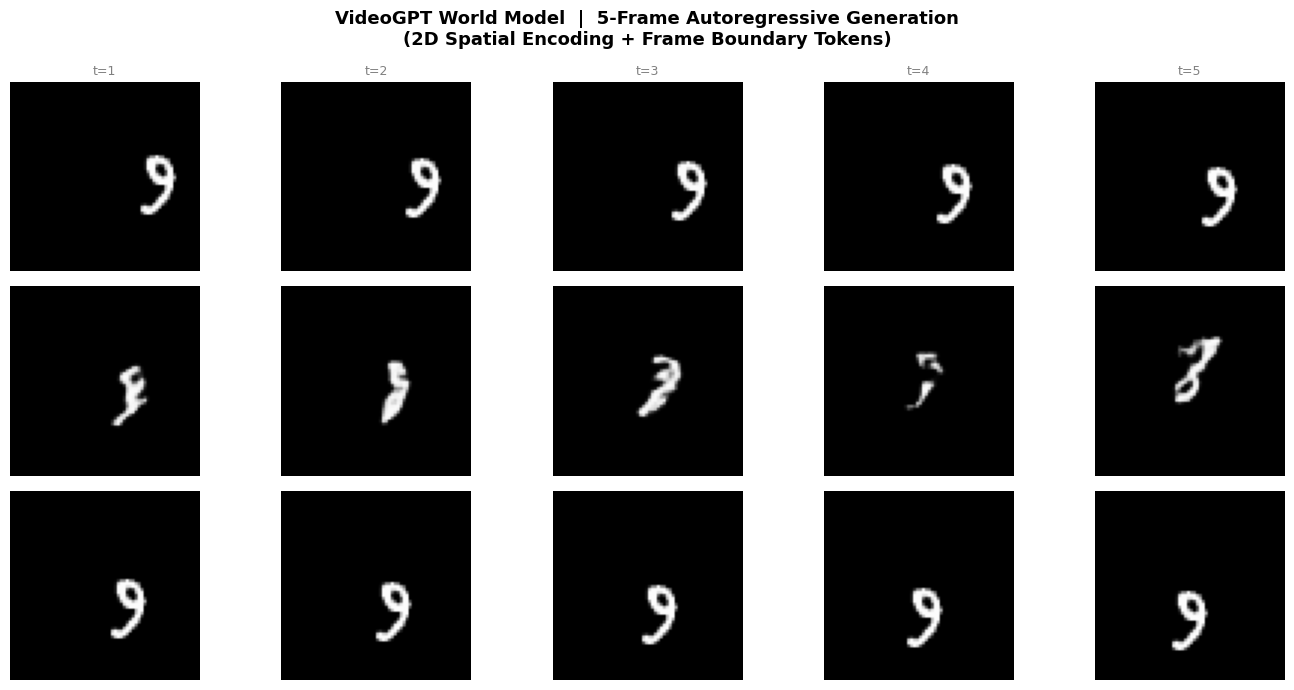

✅  Saved → gpt_predictions.png


In [35]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║ CHART: GPT Prediction Grid                                 ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(3, 5, figsize=(14, 7))
fig.suptitle('VideoGPT World Model  |  5-Frame Autoregressive Generation\n'
             '(2D Spatial Encoding + Frame Boundary Tokens)',
             fontsize=13, fontweight='bold')

row_labels = ['Context (observed)', 'GPT Generated', 'Ground Truth']
row_data   = [ctx_frames[0].cpu(), pred_frames[0], gt_frames[0]]

for r, (label, data) in enumerate(zip(row_labels, row_data)):
    for c in range(5):
        axes[r, c].imshow(data[c, 0], cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(label, fontsize=9, fontweight='bold', labelpad=6)
        if r == 0:
            axes[r, c].set_title(f't={c+1}', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/gpt_predictions.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅  Saved → gpt_predictions.png')


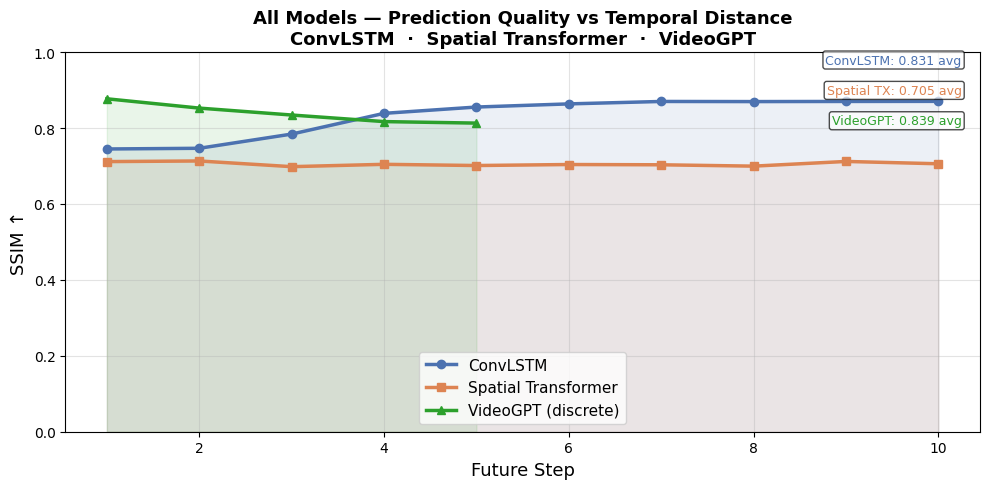

✅  Saved →all_models_ssim.png


In [36]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║ CHART: All Models SSIM Comparison                         ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(10, 5))

# ConvLSTM and Spatial TX curves (10 steps)
ax.plot(range(1, 11), ssim_conv,    marker='o', lw=2.5, label='ConvLSTM',            color='#4C72B0')
ax.plot(range(1, 11), ssim_spatial, marker='s', lw=2.5, label='Spatial Transformer',  color='#DD8452')
# GPT curve (5 steps, aligned to steps 1-5)
ax.plot(range(1, 6),  gpt_ssim_per_step, marker='^', lw=2.5, label='VideoGPT (discrete)', color='#2CA02C')

ax.fill_between(range(1, 11), ssim_conv,    alpha=0.1, color='#4C72B0')
ax.fill_between(range(1, 11), ssim_spatial, alpha=0.1, color='#DD8452')
ax.fill_between(range(1, 6),  gpt_ssim_per_step, alpha=0.1, color='#2CA02C')

ax.set_xlabel('Future Step', fontsize=13)
ax.set_ylabel('SSIM ↑', fontsize=13)
ax.set_title('All Models — Prediction Quality vs Temporal Distance\n'
             'ConvLSTM  ·  Spatial Transformer  ·  VideoGPT',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
ax.set_ylim(0, 1)

# avg SSIM annotations
for label, scores, color in [
    ('ConvLSTM',   ssim_conv,           '#4C72B0'),
    ('Spatial TX', ssim_spatial,         '#DD8452'),
    ('VideoGPT',   gpt_ssim_per_step,   '#2CA02C'),
]:
    ax.annotate(f'{label}: {np.mean(scores):.3f} avg',
                xy=(0.98, 0.97 - 0.08 * ['ConvLSTM','Spatial TX','VideoGPT'].index(label)),
                xycoords='axes fraction', ha='right', fontsize=9, color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/all_models_ssim.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅  Saved →all_models_ssim.png')


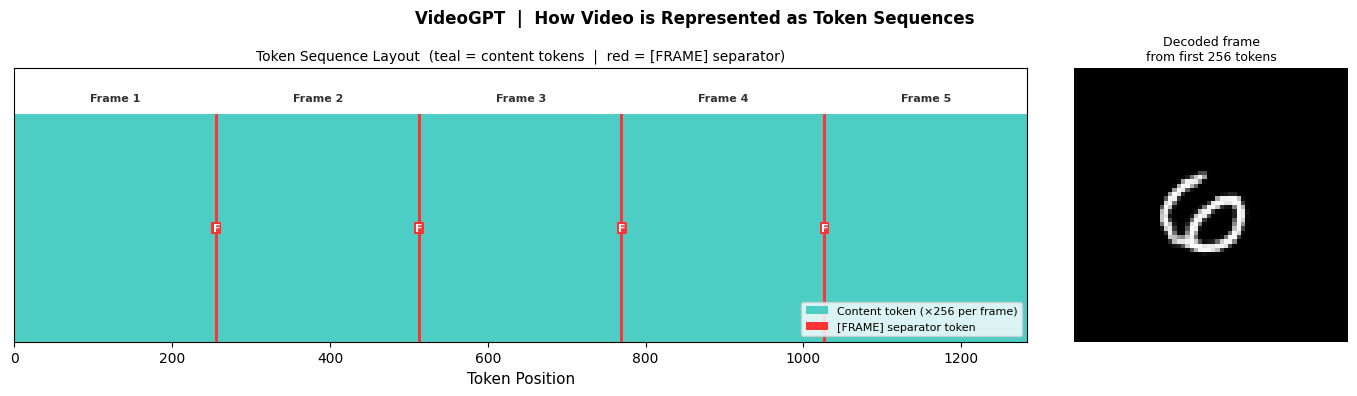

 Saved → token_visualization.png


In [37]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART: Token Sequence Visualization                                 ║
# ║  Shows what the GPT actually "sees" as input                         ║
# ╚══════════════════════════════════════════════════════════════════════╝
sample_seq = token_dataset_v2[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                          gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('VideoGPT  |  How Video is Represented as Token Sequences',
             fontsize=12, fontweight='bold')

ax = axes[0]
display_tokens = sample_seq[:5 * TOKENS_PER_FRAME + 4]   # 5 frames + 4 seps

# Step 1: draw all content tokens in teal
ax.bar(range(len(display_tokens)), [1] * len(display_tokens),
       color='#4ECDC4', width=1.0, edgecolor='none')

# Step 2: draw separator tokens on top with high visibility
sep_positions_display = [pos for pos in sep_positions if pos < len(display_tokens)]
for pos in sep_positions_display:
    ax.bar(pos, 1.0, color='#FF3333', width=4.0, edgecolor='none', zorder=5)
    ax.text(pos, 0.5, 'F', ha='center', va='center',
            color='white', fontsize=8, fontweight='bold', zorder=6,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='#FF3333', edgecolor='none'))

# Step 3: add frame labels above each block
frame_starts = [0] + [p + 1 for p in sep_positions_display]
for i, start in enumerate(frame_starts):
    end = sep_positions_display[i] if i < len(sep_positions_display) else len(display_tokens)
    mid = (start + end) / 2
    ax.text(mid, 1.05, f'Frame {i+1}', ha='center', va='bottom',
            fontsize=8, color='#333333', fontweight='bold')

ax.set_xlim(0, len(display_tokens))
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_xlabel('Token Position', fontsize=11)
ax.set_title('Token Sequence Layout  (teal = content tokens  |  red = [FRAME] separator)',
             fontsize=10)

# Step 4: legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4ECDC4', label=f'Content token (×{TOKENS_PER_FRAME} per frame)'),
    Patch(facecolor='#FF3333', label='[FRAME] separator token'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

# Right: decoded frame
ax2 = axes[1]
frame0_tokens = torch.tensor(sample_seq[:TOKENS_PER_FRAME]).unsqueeze(0).to(device)
with torch.no_grad():
    z = vqvae.vq.embedding(frame0_tokens).view(1, 16, 16, 128).permute(0, 3, 1, 2)
    decoded = vqvae.decoder(z).cpu()
ax2.imshow(decoded[0, 0], cmap='gray')
ax2.set_title('Decoded frame\nfrom first 256 tokens', fontsize=9)
ax2.axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/token_visualization.png', dpi=180, bbox_inches='tight')
plt.show()
print(' Saved → token_visualization.png')

In [39]:
# =========================================================
# LPIPS SETUP
# =========================================================

!pip install lpips -q

import lpips

# perceptual similarity model
lpips_fn = lpips.LPIPS(
    net='alex'
).to(device)

print("LPIPS ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.1 MB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 146MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS ready


In [40]:
def compute_ssim_curve(predictions, ground_truth):
    """Compute mean SSIM per future step. Both tensors: (B, T, 1, H, W) CPU."""
    scores = []
    for t in range(predictions.shape[1]):
        step_scores = [
            ssim(predictions[b, t, 0].numpy(), ground_truth[b, t, 0].numpy(), data_range=1.0)
            for b in range(predictions.shape[0])
        ]
        scores.append(np.mean(step_scores))
    return scores


def compute_lpips_curve(predictions, ground_truth, lpips_fn):
    """Compute mean LPIPS per future step. Converts grayscale→RGB for VGG."""
    scores = []
    lpips_fn.eval()
    with torch.no_grad():
        for t in range(predictions.shape[1]):
            # LPIPS expects (B, 3, H, W) in [-1, 1]
            p = predictions[:, t].repeat(1, 3, 1, 1) * 2 - 1
            g = ground_truth[:, t].repeat(1, 3, 1, 1) * 2 - 1
            score = lpips_fn(p.to(device), g.to(device)).mean().item()
            scores.append(score)
    return scores


# ── Evaluate all three models on same 32-sample batch ────────────────────
print('Running evaluation on 32-sample held-out batch...')
eval_batch = next(iter(DataLoader(dataset, batch_size=32))).to(device)
eval_input = eval_batch[:, :10]
eval_gt    = eval_batch[:, 10:].cpu()

# ConvLSTM
print('  ConvLSTM...')
preds_conv_eval    = autoregressive_rollout(vae, dynamics_model, eval_input, steps=10)
# Spatial Transformer
print('  Spatial Transformer...')
preds_spatial_eval = autoregressive_rollout(vae, spatial_model,  eval_input, steps=10)
# VideoGPT (5 steps — GPT prediction is slower)
print('  VideoGPT (5 steps)...')
eval_ctx_gpt = eval_batch[:8, :5]   # 8 samples for speed
gt_gpt       = eval_batch[:8, 5:10].cpu()
preds_gpt    = gpt_predict_frames(video_gpt, vqvae, eval_ctx_gpt, n_predict=5)

# SSIM curves
ssim_conv    = compute_ssim_curve(preds_conv_eval,    eval_gt)
ssim_spatial = compute_ssim_curve(preds_spatial_eval, eval_gt)
ssim_gpt     = compute_ssim_curve(preds_gpt,          gt_gpt)

# LPIPS curves
lpips_conv    = compute_lpips_curve(preds_conv_eval,    eval_gt,  lpips_fn)
lpips_spatial = compute_lpips_curve(preds_spatial_eval, eval_gt,  lpips_fn)
lpips_gpt     = compute_lpips_curve(preds_gpt,          gt_gpt,lpips_fn)

print(f'\nConvLSTM      avg SSIM: {np.mean(ssim_conv):.4f}   avg LPIPS: {np.mean(lpips_conv):.4f}')
print(f'Spatial TX     avg SSIM: {np.mean(ssim_spatial):.4f}   avg LPIPS: {np.mean(lpips_spatial):.4f}')
print(f'VideoGPT       avg SSIM: {np.mean(ssim_gpt):.4f}   avg LPIPS: {np.mean(lpips_gpt):.4f}')


Running evaluation on 32-sample held-out batch...
  ConvLSTM...
  Spatial Transformer...
  VideoGPT (5 steps)...

ConvLSTM      avg SSIM: 0.8380   avg LPIPS: 0.4535
Spatial TX     avg SSIM: 0.7206   avg LPIPS: 0.5132
VideoGPT       avg SSIM: 0.8394   avg LPIPS: 0.1757


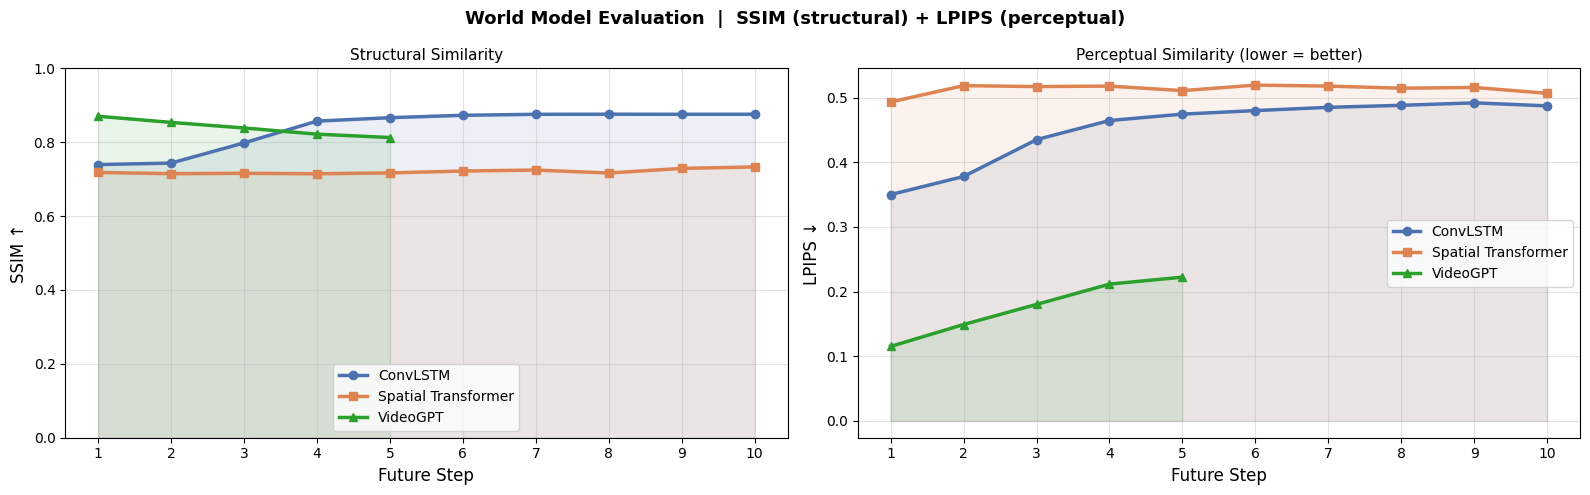

Saved -> dual_metric.png


In [41]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART 1: SSIM + LPIPS dual metric comparison                        ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('World Model Evaluation  |  SSIM (structural) + LPIPS (perceptual)',
             fontsize=13, fontweight='bold')

steps10 = list(range(1, 11))
steps5  = list(range(1, 6))

# SSIM
for steps, scores, label, color, marker in [
    (steps10, ssim_conv,    'ConvLSTM',            '#4C72B0', 'o'),
    (steps10, ssim_spatial, 'Spatial Transformer', '#DD8452', 's'),
    (steps5,  ssim_gpt,     'VideoGPT',            '#2CA02C', '^'),
]:
    ax1.plot(steps, scores, marker=marker, lw=2.5, label=label, color=color)
    ax1.fill_between(steps, scores, alpha=0.1, color=color)
ax1.set_xlabel('Future Step', fontsize=12); ax1.set_ylabel('SSIM ↑', fontsize=12)
ax1.set_title('Structural Similarity', fontsize=11)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.35); ax1.set_ylim(0, 1)
ax1.set_xticks(steps10)

# LPIPS
for steps, scores, label, color, marker in [
    (steps10, lpips_conv,    'ConvLSTM',            '#4C72B0', 'o'),
    (steps10, lpips_spatial, 'Spatial Transformer', '#DD8452', 's'),
    (steps5,  lpips_gpt,     'VideoGPT',            '#2CA02C', '^'),
]:
    ax2.plot(steps, scores, marker=marker, lw=2.5, label=label, color=color)
    ax2.fill_between(steps, scores, alpha=0.1, color=color)
ax2.set_xlabel('Future Step', fontsize=12); ax2.set_ylabel('LPIPS ↓', fontsize=12)
ax2.set_title('Perceptual Similarity (lower = better)', fontsize=11)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.35)
ax2.set_xticks(steps10)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/dual_metric.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved -> dual_metric.png')


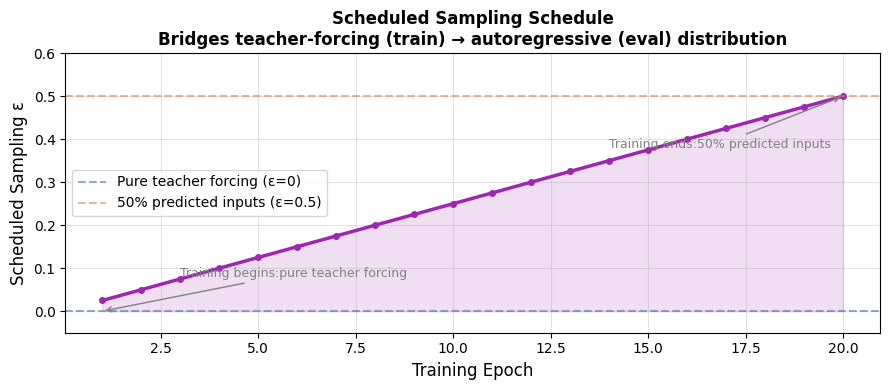

Saved -> scheduled_sampling.png


In [42]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART 2: Scheduled Sampling — epsilon annealing curve               ║
# ╚══════════════════════════════════════════════════════════════════════╝
epochs_range = list(range(1, 21))
epsilons     = [min(0.5, (e / 20) * 0.5) for e in epochs_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_range, epsilons, color='#9C27B0', lw=2.5, marker='o', markersize=4)
ax.fill_between(epochs_range, epsilons, alpha=0.15, color='#9C27B0')
ax.axhline(0.0, color='#4C72B0', lw=1.5, linestyle='--', alpha=0.6, label='Pure teacher forcing (ε=0)')
ax.axhline(0.5, color='#DD8452', lw=1.5, linestyle='--', alpha=0.6, label='50% predicted inputs (ε=0.5)')
ax.set_xlabel('Training Epoch', fontsize=12)
ax.set_ylabel('Scheduled Sampling ε', fontsize=12)
ax.set_title('Scheduled Sampling Schedule\n'
             'Bridges teacher-forcing (train) → autoregressive (eval) distribution',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.35); ax.set_ylim(-0.05, 0.6)
ax.annotate('Training begins:pure teacher forcing', xy=(1, 0), xytext=(3, 0.08),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('Training ends:50% predicted inputs', xy=(20, 0.5), xytext=(14, 0.38),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/scheduled_sampling.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved -> scheduled_sampling.png')


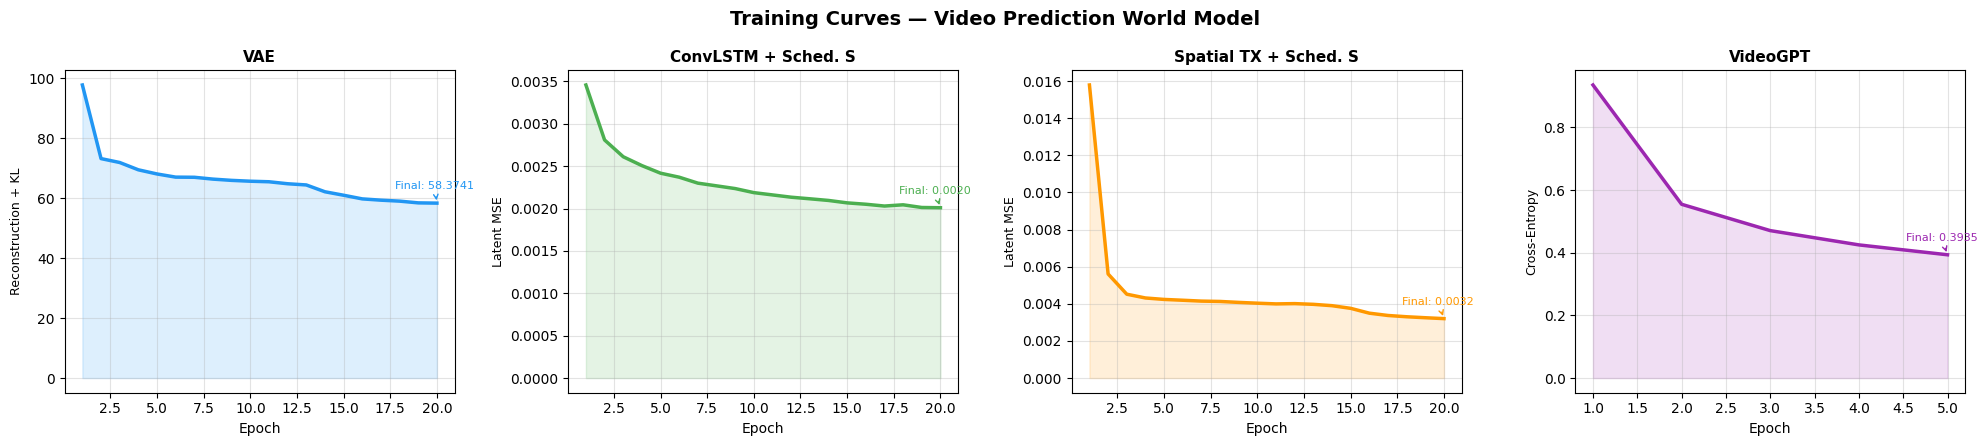

Saved -> training_curves.png


In [43]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART 3: Training Loss Curves — All Models                          ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle('Training Curves — Video Prediction World Model', fontsize=14, fontweight='bold')

configs = [
    (axes[0], vae_train_losses,  '#2196F3', 'VAE',                 'Reconstruction + KL'),
    (axes[1], dynamics_losses,   '#4CAF50', 'ConvLSTM + Sched. S', 'Latent MSE'),
    (axes[2], spatial_losses,    '#FF9800', 'Spatial TX + Sched. S','Latent MSE'),
    (axes[3], gpt_losses_v2,     '#9C27B0', 'VideoGPT',            'Cross-Entropy'),
]
for ax, losses, color, name, ylabel in configs:
    x = list(range(1, len(losses) + 1))
    ax.plot(x, losses, color=color, lw=2.5)
    ax.fill_between(x, losses, alpha=0.15, color=color)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10); ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.35)
    ax.annotate(f'Final: {losses[-1]:.4f}',
                xy=(len(losses), losses[-1]), xytext=(-30, 10),
                textcoords='offset points', fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color))
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/training_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved -> training_curves.png')


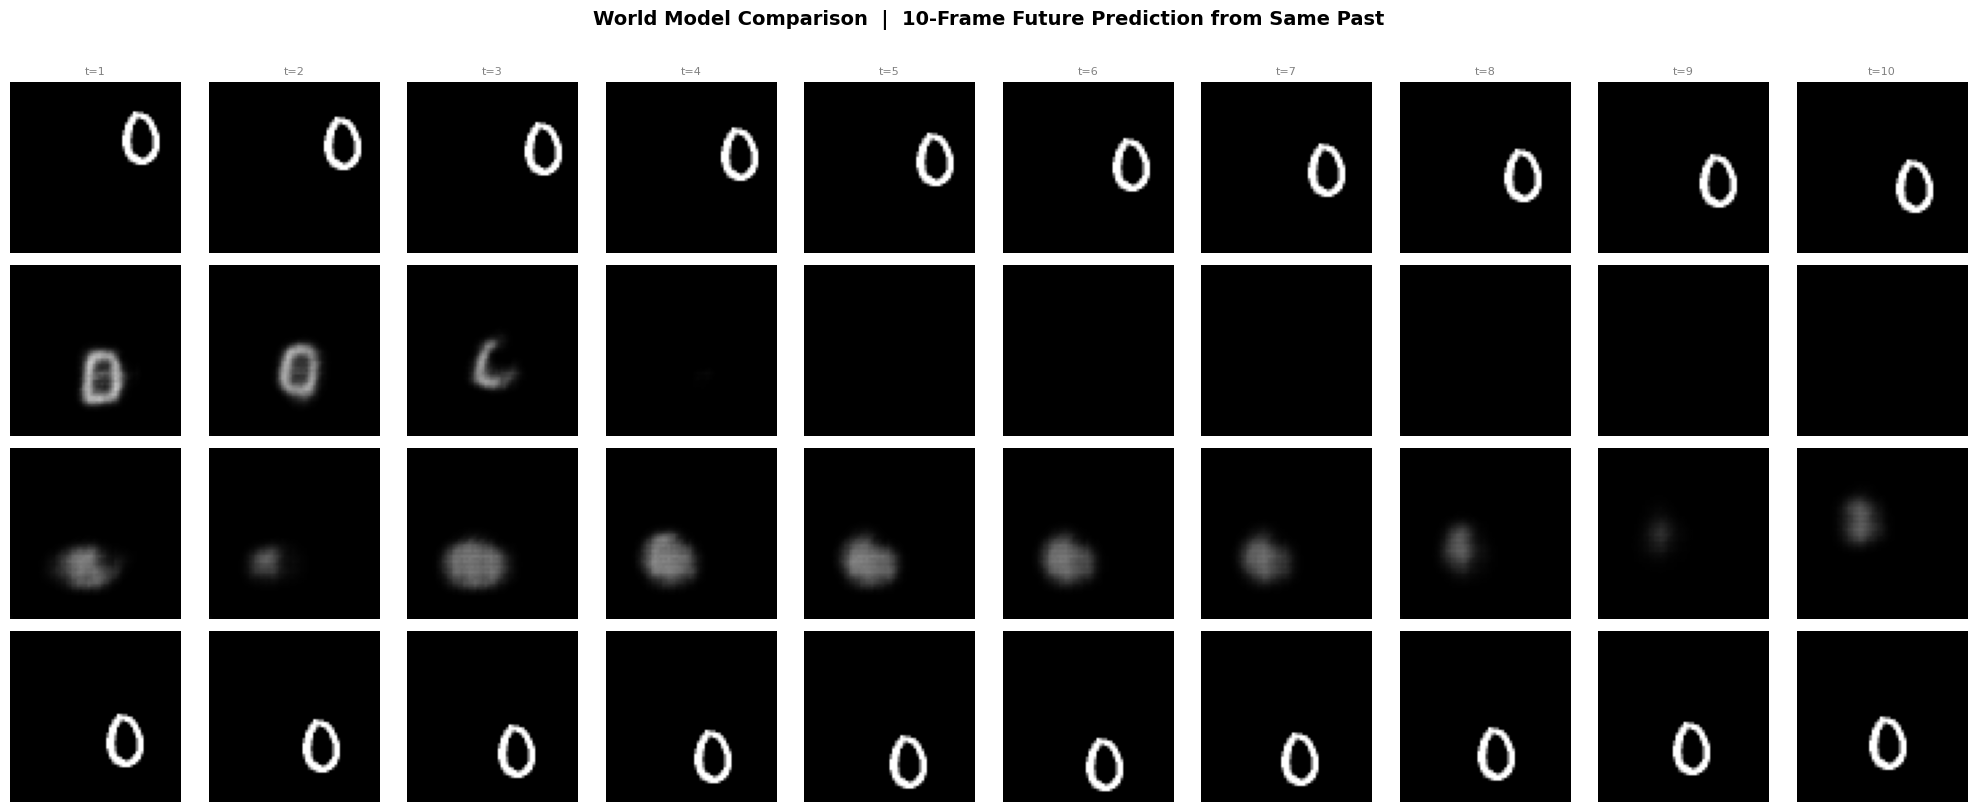

Saved -> model_comparison.png


In [44]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART 4: Model Comparison Grid                                      ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig = plt.figure(figsize=(20, 8))
fig.suptitle('World Model Comparison  |  10-Frame Future Prediction from Same Past',
             fontsize=14, fontweight='bold', y=1.01)
n_show = 10
for r, (frames_data, label, color) in enumerate([
    (input_seq[0].cpu(),  'Observed Past',        '#555555'),
    (preds_convlstm[0],   'ConvLSTM Prediction',  '#4C72B0'),
    (preds_spatial[0],    'Spatial TX Prediction', '#DD8452'),
    (target_seq[0].cpu(), 'Ground Truth Future',   '#2CA02C'),
]):
    for c in range(n_show):
        ax = fig.add_subplot(4, n_show, r * n_show + c + 1)
        ax.imshow(frames_data[c, 0], cmap='gray', vmin=0, vmax=1); ax.axis('off')
        if c == 0: ax.set_ylabel(label, fontsize=9, color=color, fontweight='bold', labelpad=6)
        if r == 0: ax.set_title(f't={c+1}', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved -> model_comparison.png')


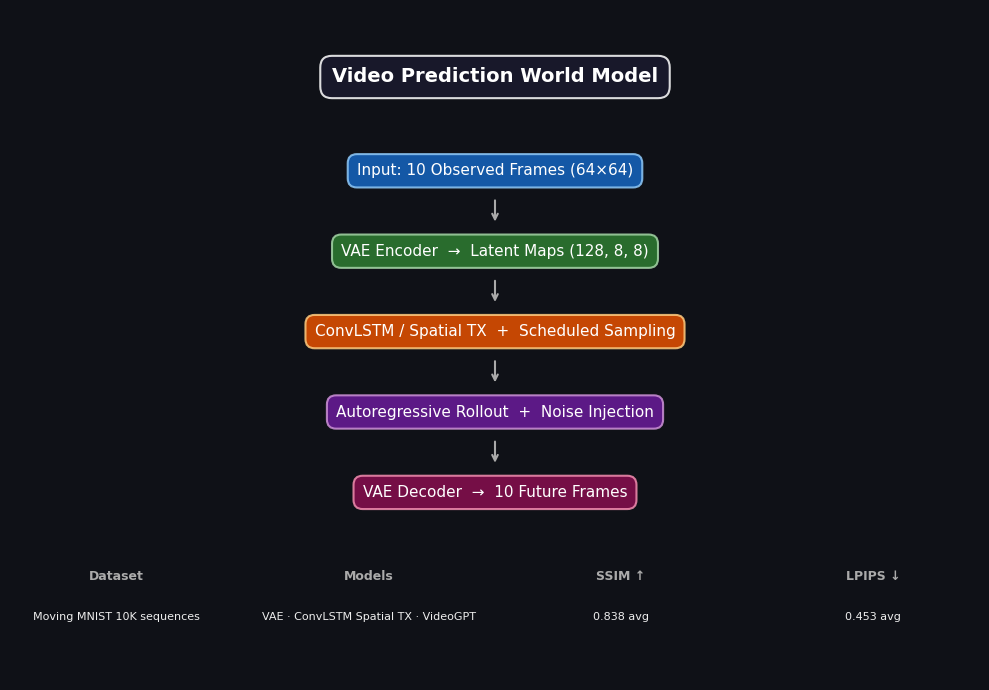

Saved -> architecture_card.png


In [45]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART 6: Architecture Card                                          ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('#0f1117'); ax.set_facecolor('#0f1117')
box_kw = dict(boxstyle='round,pad=0.6', linewidth=1.5)
for (x, y, txt, ec, fc, fs, bold) in [
    (5, 9.0, 'Video Prediction World Model',             '#ffffff', '#1a1a2e', 14, True),
    (5, 7.6, 'Input: 10 Observed Frames (64×64)',         '#90CAF9', '#1565C0', 11, False),
    (5, 6.4, 'VAE Encoder  →  Latent Maps (128, 8, 8)',   '#A5D6A7', '#2E7D32', 11, False),
    (5, 5.2, 'ConvLSTM / Spatial TX  +  Scheduled Sampling','#FFCC80','#E65100',11, False),
    (5, 4.0, 'Autoregressive Rollout  +  Noise Injection', '#CE93D8', '#6A1B9A', 11, False),
    (5, 2.8, 'VAE Decoder  →  10 Future Frames',          '#F48FB1', '#880E4F', 11, False),
]:
    ax.text(x, y, txt, fontsize=fs, fontweight='bold' if bold else 'normal',
            ha='center', va='center', color='white',
            bbox=dict(**box_kw, edgecolor=ec, facecolor=fc, alpha=0.85))
for y_top, y_bot in [(7.2, 6.8), (6.0, 5.6), (4.8, 4.4), (3.6, 3.2)]:
    ax.annotate('', xy=(5, y_bot), xytext=(5, y_top),
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1.5))
best_ssim = max(np.mean(ssim_conv), np.mean(ssim_spatial))
best_lpips = min(np.mean(lpips_conv), np.mean(lpips_spatial))
for i, (k, v) in enumerate([
    ('Dataset',   'Moving MNIST 10K sequences'),
    ('Models',    'VAE · ConvLSTM Spatial TX · VideoGPT'),
    ('SSIM ↑',    f'{best_ssim:.3f} avg'),
    ('LPIPS ↓',   f'{best_lpips:.3f} avg'),
]):
    xpos = 1.1 + i * 2.6
    ax.text(xpos, 1.5, k, fontsize=9,  color='#aaaaaa', ha='center', fontweight='bold')
    ax.text(xpos, 0.9, v, fontsize=8,  color='#eeeeee', ha='center')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/architecture_card.png', dpi=200, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Saved -> architecture_card.png')


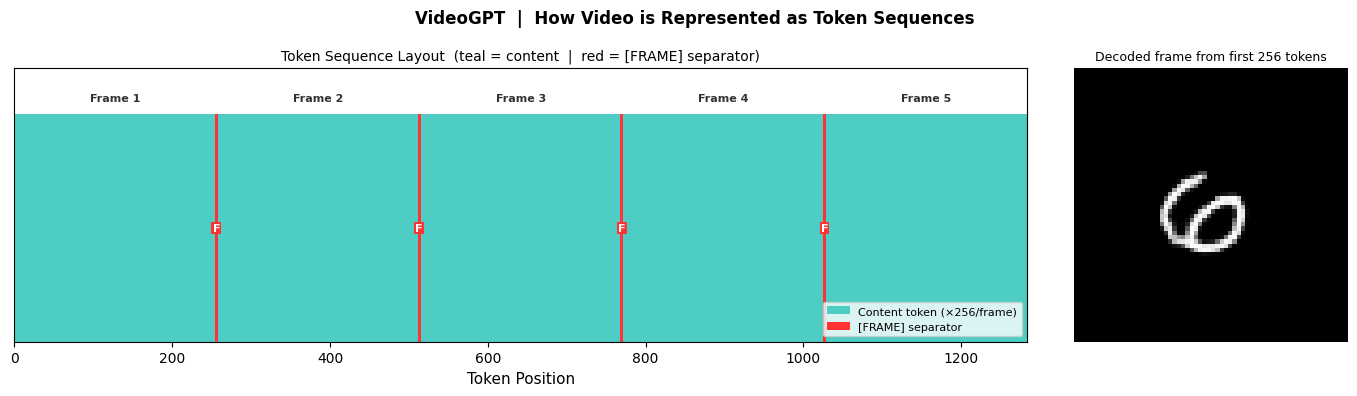

Saved -> token_visualization.png


In [46]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHART 7: Token Sequence Visualization                               ║
# ╚══════════════════════════════════════════════════════════════════════╝
sample_seq = token_dataset_v2[0].numpy()
fig, axes  = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('VideoGPT  |  How Video is Represented as Token Sequences',
             fontsize=12, fontweight='bold')
ax = axes[0]
display_tokens = sample_seq[:5 * TOKENS_PER_FRAME + 4]
ax.bar(range(len(display_tokens)), [1]*len(display_tokens), color='#4ECDC4', width=1.0, edgecolor='none')
sep_pos_display = [p for p in sep_positions if p < len(display_tokens)]
for pos in sep_pos_display:
    ax.bar(pos, 1.0, color='#FF3333', width=4.0, edgecolor='none', zorder=5)
    ax.text(pos, 0.5, 'F', ha='center', va='center', color='white', fontsize=8,
            fontweight='bold', zorder=6,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='#FF3333', edgecolor='none'))
frame_starts = [0] + [p + 1 for p in sep_pos_display]
for i, start in enumerate(frame_starts):
    end = sep_pos_display[i] if i < len(sep_pos_display) else len(display_tokens)
    ax.text((start + end) / 2, 1.05, f'Frame {i+1}', ha='center', va='bottom',
            fontsize=8, color='#333333', fontweight='bold')
ax.set_xlim(0, len(display_tokens)); ax.set_ylim(0, 1.2); ax.set_yticks([])
ax.set_xlabel('Token Position', fontsize=11)
ax.set_title('Token Sequence Layout  (teal = content  |  red = [FRAME] separator)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(facecolor='#4ECDC4', label=f'Content token (×{TOKENS_PER_FRAME}/frame)'),
    mpatches.Patch(facecolor='#FF3333', label='[FRAME] separator'),
], loc='lower right', fontsize=8)
ax2 = axes[1]
tok0 = torch.tensor(sample_seq[:TOKENS_PER_FRAME]).unsqueeze(0).to(device)
with torch.no_grad():
    z = vqvae.vq.embedding(tok0).view(1, 16, 16, 128).permute(0, 3, 1, 2)
    dec = vqvae.decoder(z).cpu()
ax2.imshow(dec[0, 0], cmap='gray'); ax2.set_title('Decoded frame from first 256 tokens', fontsize=9)
ax2.axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/token_visualization.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved -> token_visualization.png')
